# Olist Brazilian E-Commerce — Consolidated EDA
## Team 5 · IT5006 · AY2026/27 Semester 1 — Phase 1 (Literature Review & EDA)

Covers the dataset and
data quality, temporal patterns, the customer / seller / product distributions, relationships between
variables, and a preliminary investigation of the candidate analytics problems to be scoped in
Phase 2. Every chart is read for two things: **what it implies for our choice of problem**, and
**whether the underlying data is usable**.

*Team 5 — Gan Zi Qing, Lam Pei Shi, Li Keyou, Lim Yunhui Trixie, Siow Hui Xin.*

## 0. Setup and data loading

We load the nine Olist tables, parsing all date columns up front. The loader searches a list of
common locations (Colab Drive, the repo `data/` folder, an `OLIST_DATA_DIR` override) so the same
notebook runs unchanged for every team member. The shape of each table is printed to get an overview of the data that we are working with.

Some shared settings for libraries are also set here.

In [59]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

RANDOM_STATE = 42   # documented seed, used for every sampling / split below
np.random.seed(RANDOM_STATE)

In [60]:
# Try to mount Google Drive when running on Colab (silently skipped elsewhere)
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

def find_data_dir():
    candidates = []
    if os.environ.get("OLIST_DATA_DIR"):
        candidates.append(os.environ["OLIST_DATA_DIR"])
    candidates += [
        "/content/drive/MyDrive/IT5006_Project/Olist_CSV",
        "/content/drive/Othercomputers/My laptop/NUS/11_IT5006 Fundamentals of Data Analytics/03_Project/IT5006_Project-Data/Olist_CSV",
        "data", "../data", "Olist_CSV", "../Olist_CSV",
    ]
    for c in candidates:
        if c and os.path.exists(os.path.join(c, "olist_orders_dataset.csv")):
            return c
    raise FileNotFoundError(
        "Could not locate the Olist CSVs. Set OLIST_DATA_DIR or place the files in ./data/.")

DATA_DIR = find_data_dir()
print("Reading data from:", DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading data from: /content/drive/Othercomputers/My laptop/NUS/11_IT5006 Fundamentals of Data Analytics/03_Project/IT5006_Project-Data/Olist_CSV


In [61]:
DATE_COLS = {
    "orders": ["order_purchase_timestamp", "order_approved_at",
               "order_delivered_carrier_date", "order_delivered_customer_date",
               "order_estimated_delivery_date"],
    "items": ["shipping_limit_date"],
    "reviews": ["review_creation_date", "review_answer_timestamp"],
}
FILES = {
    "orders": "olist_orders_dataset.csv", "items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv", "reviews": "olist_order_reviews_dataset.csv",
    "customers": "olist_customers_dataset.csv", "sellers": "olist_sellers_dataset.csv",
    "products": "olist_products_dataset.csv", "geolocation": "olist_geolocation_dataset.csv",
    "cat_trans": "product_category_name_translation.csv",
}
t = {name: pd.read_csv(os.path.join(DATA_DIR, fn), parse_dates=DATE_COLS.get(name))
     for name, fn in FILES.items()}
for name, df in t.items():
    print(f"{name:14s} {df.shape[0]:>9,} rows x {df.shape[1]} cols")

orders            99,441 rows x 8 cols
items            112,650 rows x 7 cols
payments         103,886 rows x 5 cols
reviews           99,224 rows x 7 cols
customers         99,441 rows x 5 cols
sellers            3,095 rows x 4 cols
products          32,951 rows x 9 cols
geolocation    1,000,163 rows x 5 cols
cat_trans             71 rows x 2 cols


## 1. Dataset overview — tables, joins, row counts

To get a sense of how the dataset tables are related, we first reviewed which tables share the same headers. These are potential join keys. The dataset is nine relational tables centred on `orders` and `order_items`.
We reviewed the dataset and also took references from other ERD diagrams found on the Kaggle website. The final ERD diagram is presented in the report.

Data Structure:
* `orders` and `reviews` are one row per order
* `customers` is one row per customer_id, each customer_unique_id can have several entries
* `order_items` is one row per **item line**, and an order can have several entries distinguished by the order_item_id
* `payments` is one row per payment instalment record, and an order can have multiple entries distinguished by payment_installments

A few structural facts the whole team relies on:
- `customer_id` is issued **per order**; the real person is `customer_unique_id`.
- `order_items.order_item_id` is a line counter within an order (max 21), not a product id.
- `geolocation` has many rows per zip prefix and ~262k exact duplicates, so it must be reduced to one coordinate per zip before use

In [62]:
# Which columns are shared across tables — i.e. the join keys
from collections import defaultdict
col_tables = defaultdict(list)
for name, df in t.items():
    for c in df.columns:
        col_tables[c].append(name)
print("Join keys (columns shared by >1 table):")
for c, v in col_tables.items():
    if len(v) > 1:
        print(f"  {c:26s} links  {', '.join(v)}")

Join keys (columns shared by >1 table):
  order_id                   links  orders, items, payments, reviews
  customer_id                links  orders, customers
  product_id                 links  items, products
  seller_id                  links  items, sellers
  product_category_name      links  products, cat_trans


In [63]:
overview = []
for name, df in t.items():
    overview.append({
        "table": name, "rows": len(df), "cols": df.shape[1],
        "total_missing_cells": int(df.isna().sum().sum()),
        "exact_dup_rows": int(df.duplicated().sum()),
    })
overview = pd.DataFrame(overview).set_index("table")
overview

,rows,cols,total_missing_cells,exact_dup_rows
table,,,,
orders,99441,8,4908,0
items,112650,7,0,0
payments,103886,5,0,0
reviews,99224,7,145903,0
customers,99441,5,0,0
sellers,3095,4,0,0
products,32951,9,2448,0
geolocation,1000163,5,0,261831
cat_trans,71,2,0,0


In [64]:
print("Distinct customer_id       :", t['customers']['customer_id'].nunique())
print("Distinct customer_unique_id:", t['customers']['customer_unique_id'].nunique())
print("Orders in order_items      :", t['items']['order_id'].nunique(),
      "| max items in one order:", int(t['items']['order_item_id'].max()))
print("Geolocation rows           :", len(t['geolocation']),
      "| distinct zip prefixes:", t['geolocation']['geolocation_zip_code_prefix'].nunique())
print("Date range (purchases)     :",
      t['orders']['order_purchase_timestamp'].min().date(), "to",
      t['orders']['order_purchase_timestamp'].max().date())

Distinct customer_id       : 99441
Distinct customer_unique_id: 96096
Orders in order_items      : 98666 | max items in one order: 21
Geolocation rows           : 1000163 | distinct zip prefixes: 19015
Date range (purchases)     : 2016-09-04 to 2018-10-17


## 2. Data quality

To review the data quality, we reviewed the number of missing fields in each table.

### 2.1 Missing Data
##### **Table: Orders**
Following the results above, we manually inspect the data to see what could be the causes of the missing rows.
For the orders table, the missing rows is likely not an error, but rather that some order dates are not available for certain entries. E.g. if the order was cancelled before it is approved, it would only contain the order_purchase_timestamp and order_estimated_delivery_date, with the rest of the date columns left empty.

This finding highlights that any further analysis related to order dates will have to account for this behaviour in the data.

##### **Table: Reviews**
There is a high percentage of missing fields in the reviews table for the comments title and message. This finding highlights that if we wanted to do any analysis related to review title or message, it will severely limit the size of the dataset that we have. Instead, analysis that involve the Review table should take information from the review_score column instead, which does not have any missing fields.  

##### **Table: Product**
While there are missing data found in this table, they are a relatively small percentage of the dataset. Nonetheless, these rows should be removed from the dataset prior to analysis if they are relevant to the analysis.

### 2.2 Other Data Issues
City name columns are unreliable
* Affected columns: `geolocation_city`, `customer_city`, `seller_city`
* Issue: The same city under accented and plain spellings plus stray HTML-/URL-encoded and parenthetical values, this will cause issues when using the city names as
* Example: `sao paulo` 135.8k rows vs `são paulo` 24.9k

Freight Ratio
* Affected columns: 'freight_value'
* Some freight values = 0, this will cause issues when calculating freight ratios due to division by 0
* Only a small subset of data falls within this category (< 0.4 %)

Circle Distance instead of Road Distance
* Distance is calculated between two points, but road distance is not available
* This is not the best representation of the actual distance covered during delivery

### 2.3 Missing-data and outlier handling decisions

Summary of preprocessing logic is documented here so Phase 2 preprocessing is reproducible:

| Issue | Extent | Decision |
|---|---|---|
| Review comment text mostly empty | ~59-88% | Do not do text based analysis; use numeric `review_score`. |
| Delivery timestamps missing | ~3% | Restrict delivery analysis to delivered orders; never use delivery dates as predictors. |
| Product category / dimensions missing | ~2% | Impute category as "unknown"; drop the few rows missing weight/volume for physical-attribute modelling. |
| Geolocation out-of-Brazil + duplicates | 42 rows + ~262k dup | Bounding-box filter, then median lat/long per zip prefix |
| City-name columns unreliable | all rows | Do not use the city-name columns for joining or grouping. Key on `zip_code_prefix` and the lat/long centroids instead |
| `freight_ratio` when price = 0 | <0.4% | Exclude these rows in analysis as division is undefined |
| Right-skewed money (price, freight) | long tail | Keep rows, but use **log-transform** for modelling, clip only for chart legibility - do not delete high-value orders. |
| Extreme freight residuals | by design | These are the anomaly *signal* in Candidate problem A, not noise to remove. |
| Circle Distance | all rows | Limitation of analysis |


In [65]:
col_missing = []

for name, df in t.items():
    counts = df.isna().sum()
    for col, missing_count in counts.items():
        col_missing.append({
            "table": name,
            "column": col,
            "missing_rows": int(missing_count),
            "missing_pct": round((missing_count / len(df)) * 100, 2),
        })

missing_df = pd.DataFrame(col_missing)

# View only columns that actually have missing data
missing_only = missing_df[missing_df["missing_rows"] > 0]
missing_only

,table,column,missing_rows,missing_pct
4,orders,order_approved_at,160,0.16
5,orders,order_delivered_carrier_date,1783,1.79
6,orders,order_delivered_customer_date,2965,2.98
23,reviews,review_comment_title,87656,88.34
24,reviews,review_comment_message,58247,58.70
37,products,product_category_name,610,1.85
38,products,product_name_lenght,610,1.85
39,products,product_description_lenght,610,1.85
40,products,product_photos_qty,610,1.85
41,products,product_weight_g,2,0.01


In [66]:
# Quantify the extremes we then decide how to treat (see table below)
it = t["items"].copy()
it["fr"] = it.freight_value / it.price.replace(0, np.nan)
print("Item price    - p50 %.2f  p99 %.2f  max %.2f" % (it.price.median(), it.price.quantile(.99), it.price.max()))
print("Freight value - p50 %.2f  p99 %.2f  max %.2f" % (it.freight_value.median(), it.freight_value.quantile(.99), it.freight_value.max()))
print("Items where freight > price (ratio > 1): %.1f%%" % ((it.fr > 1).mean()*100))
print("Zero-price items: %d | zero-freight items: %d" % ((it.price <= 0).sum(), (it.freight_value <= 0).sum()))
import unicodedata
gc = t["geolocation"]["geolocation_city"].astype(str)
folded = gc.map(lambda s: unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode())
exact = int((gc == "sao paulo").sum())
accented = int(((folded == "sao paulo") & (gc != "sao paulo")).sum())
print("City-name split - 'sao paulo' plain: %d rows; accented spelling(s) of the same city: %d rows" % (exact, accented))

Item price    - p50 74.99  p99 890.00  max 6735.00
Freight value - p50 16.26  p99 84.52  max 409.68
Items where freight > price (ratio > 1): 3.7%
Zero-price items: 0 | zero-freight items: 383
City-name split - 'sao paulo' plain: 135800 rows; accented spelling(s) of the same city: 24919 rows


In [67]:
# Count of orders where total freight is exactly 0

zero_freight_count = ((t["items"]["freight_value"] == 0)).sum()
print(f"Orders with 0 freight_value: {zero_freight_count}, {zero_freight_count/(len(t["items"]))*100}")


Orders with 0 freight_value: 383, 0.33999112294718153


## 3. Building the analytical tables

Two tables are assembled once here and reused throughout:

1. **`item`** — one row per order-item line, enriched with product physical attributes, seller and
   customer geography, seller→customer great-circle distance, and freight-to-price ratio. This is
   the basis for the freight work (section 7– section 8).
2. **`order`** — one row per order, aggregating items and payments, joined to delivery timing,
   review score, customer geography and a representative product category. This is the basis for the
   temporal, customer and delivery work (section 4–section 6).

*Geolocation is cleaned by dropping coordinates outside Brazil's bounding box, then taking the median
lat/long per zip prefix (robust to the remaining scatter).*

In [68]:
# ---- 3.1 One clean coordinate per zip prefix ----
BR_LAT = (-34.0, 5.5); BR_LON = (-74.0, -34.0)
geo = t["geolocation"]
geo = geo[geo.geolocation_lat.between(*BR_LAT) & geo.geolocation_lng.between(*BR_LON)]
geo_centroid = (geo.groupby("geolocation_zip_code_prefix")
                .agg(lat=("geolocation_lat", "median"), lng=("geolocation_lng", "median"))
                .reset_index().rename(columns={"geolocation_zip_code_prefix": "zip"}))
print("Zip prefixes with a resolved centroid:", len(geo_centroid))

Zip prefixes with a resolved centroid: 19010


In [69]:
# ---- 3.2 Products: English category + physical size features ----
prod = t["products"].merge(t["cat_trans"], on="product_category_name", how="left")
prod["category"] = (prod["product_category_name_english"]
                    .fillna(prod["product_category_name"]).fillna("unknown"))
prod["volume_cm3"] = (prod["product_length_cm"] * prod["product_height_cm"]
                      * prod["product_width_cm"])
prod["volumetric_weight_kg"] = prod["volume_cm3"] / 5000.0   # courier dimensional-weight rule
prod["weight_kg"] = prod["product_weight_g"] / 1000.0

In [70]:
# ---- 3.3 Haversine distance ----
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# ---- 3.4 Item-level table ----
sellers_geo = (t["sellers"].merge(geo_centroid, left_on="seller_zip_code_prefix",
                                  right_on="zip", how="left")
               .rename(columns={"lat": "sell_lat", "lng": "sell_lng"}))
cust_geo = (t["customers"].merge(geo_centroid, left_on="customer_zip_code_prefix",
                                 right_on="zip", how="left")
            .rename(columns={"lat": "cust_lat", "lng": "cust_lng"}))

item = (t["items"]
        .merge(t["orders"][["order_id", "customer_id", "order_status",
                            "order_purchase_timestamp"]], on="order_id", how="left")
        .merge(prod[["product_id", "category", "weight_kg", "volumetric_weight_kg", "volume_cm3"]],
               on="product_id", how="left")
        .merge(sellers_geo[["seller_id", "sell_lat", "sell_lng", "seller_state"]],
               on="seller_id", how="left")
        .merge(cust_geo[["customer_id", "cust_lat", "cust_lng", "customer_state"]],
               on="customer_id", how="left"))

item["distance_km"] = haversine_km(item.sell_lat, item.sell_lng, item.cust_lat, item.cust_lng)
item["freight_ratio"] = item["freight_value"] / item["price"].replace(0, np.nan)
print("item table:", item.shape,
      "| distance coverage: %.1f%%" % (item.distance_km.notna().mean()*100))

item table: (112650, 22) | distance coverage: 99.5%


In [71]:
# ---- 3.5 Order-level master table ----
items_agg = (t["items"].groupby("order_id")
             .agg(n_items=("order_item_id", "count"),
                  item_total=("price", "sum"),
                  freight_total=("freight_value", "sum"),
                  n_sellers=("seller_id", "nunique")).reset_index())
pay_agg = (t["payments"].groupby("order_id")
           .agg(payment_total=("payment_value", "sum"),
                max_installments=("payment_installments", "max"),
                n_payment_rows=("payment_sequential", "count")).reset_index())
pay_type = (t["payments"].sort_values("payment_value", ascending=False)
            .drop_duplicates("order_id")[["order_id", "payment_type"]]
            .rename(columns={"payment_type": "primary_payment_type"}))
rev = (t["reviews"].sort_values("review_creation_date")
       .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]])
# representative category = category of the most expensive line
item_cat = (t["items"].merge(prod[["product_id", "category"]], on="product_id", how="left")
            .sort_values("price", ascending=False).drop_duplicates("order_id")
            [["order_id", "category"]])

order = (t["orders"]
         .merge(t["customers"][["customer_id", "customer_unique_id",
                                "customer_state"]], on="customer_id", how="left")
         .merge(items_agg, on="order_id", how="left")
         .merge(pay_agg, on="order_id", how="left")
         .merge(pay_type, on="order_id", how="left")
         .merge(rev, on="order_id", how="left")
         .merge(item_cat, on="order_id", how="left"))
order["order_total"] = order["item_total"].fillna(0) + order["freight_total"].fillna(0)
order["freight_ratio"] = order["freight_total"] / order["item_total"].replace(0, np.nan)

# timing (only meaningful for delivered orders)
order["delivery_days"] = (order.order_delivered_customer_date
                          - order.order_purchase_timestamp).dt.days
order["est_days"] = (order.order_estimated_delivery_date
                     - order.order_purchase_timestamp).dt.days
order["days_late"] = (order.order_delivered_customer_date
                      - order.order_estimated_delivery_date).dt.days
order["is_late"] = order["days_late"] > 0
order["purchase_month"] = order.order_purchase_timestamp.dt.to_period("M").astype(str)
order["purchase_dow"] = order.order_purchase_timestamp.dt.day_name()
order["purchase_hour"] = order.order_purchase_timestamp.dt.hour
print("order table:", order.shape)

order table: (99441, 29)


## 4. Temporal patterns

Order volume and revenue over the ~two-year window, plus the intraweek rhythm of when customers buy.

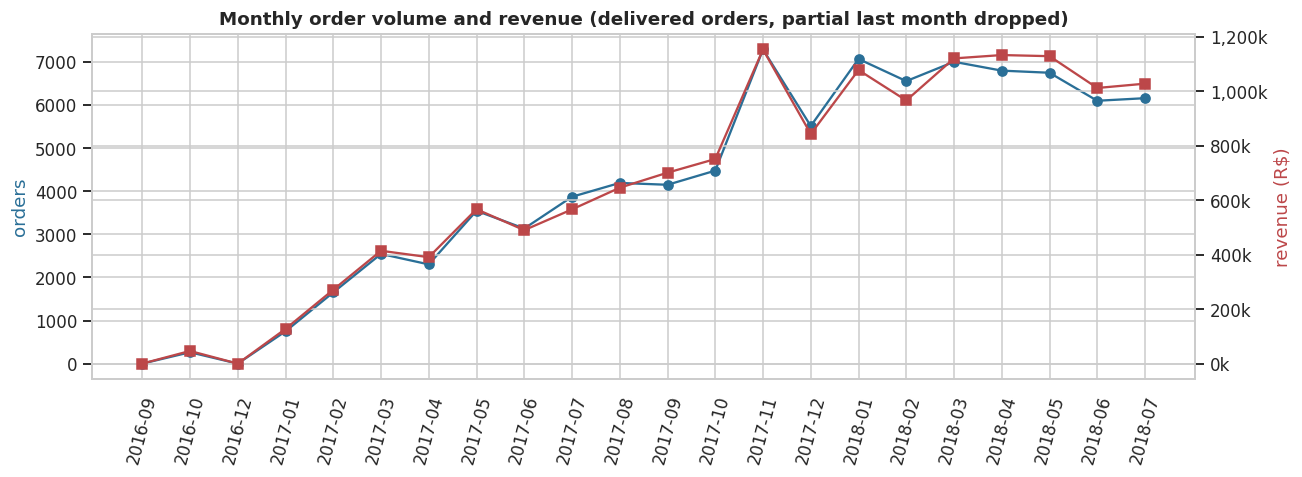

In [72]:
delivered = order[order.order_status == "delivered"].copy()
monthly = (delivered.groupby("purchase_month")
           .agg(orders=("order_id", "nunique"), revenue=("order_total", "sum")).reset_index())
# drop the partial final month for a fair trend
monthly = monthly.iloc[:-1] if len(monthly) > 2 else monthly

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(monthly.purchase_month, monthly.orders, marker="o", color="#2A6F97", label="orders")
ax1.set_ylabel("orders", color="#2A6F97"); ax1.tick_params(axis="x", rotation=75)
ax2 = ax1.twinx()
ax2.plot(monthly.purchase_month, monthly.revenue, marker="s", color="#BC4749", label="revenue")
ax2.set_ylabel("revenue (R$)", color="#BC4749")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax1.set_title("Monthly order volume and revenue (delivered orders, partial last month dropped)")
plt.tight_layout(); plt.show()

The marketplace grows steadily through 2017–2018 with a pronounced **November 2017 spike
(Black Friday)**. Any time-based model should use time-ordered splits and can benefit from a
month / holiday feature.

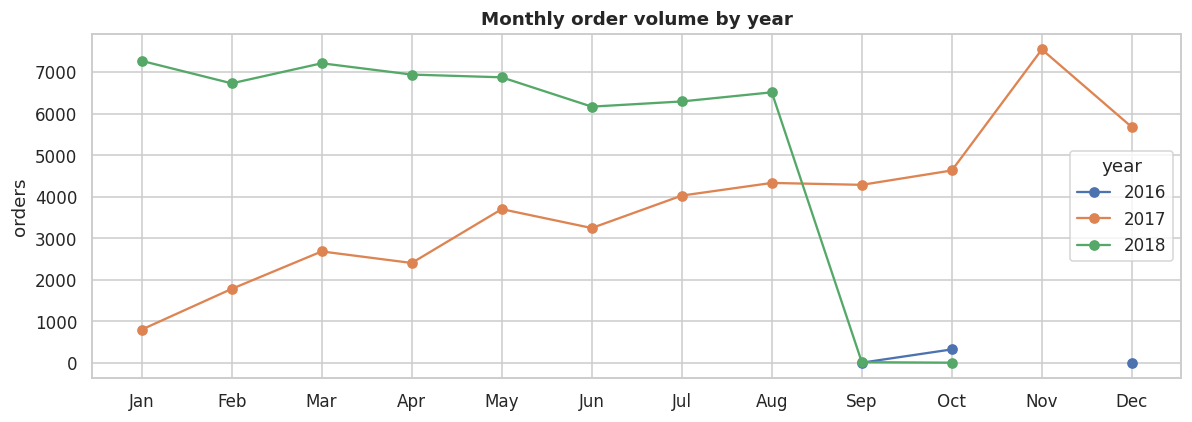

In [73]:
# Year-over-year monthly volume — makes seasonality explicit
oy = t["orders"].copy()
oy["year"] = oy.order_purchase_timestamp.dt.year
oy["mon"] = oy.order_purchase_timestamp.dt.month
piv = oy.groupby(["mon", "year"]).order_id.count().unstack("year")
fig, ax = plt.subplots(figsize=(11, 4))
for yr in piv.columns:
    ax.plot(piv.index, piv[yr], marker="o", label=str(int(yr)))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("orders"); ax.set_title("Monthly order volume by year"); ax.legend(title="year")
plt.tight_layout(); plt.show()

Overlaying the years shows the platform scaling (2018 sits above 2017 for most months) and marks
the **November 2017 Black Friday** peak as a one-off rather than a recurring seasonal pattern. The
window is only ~2 years (late 2016 to Oct 2018) with a partial final month, so seasonal claims stay
cautious.

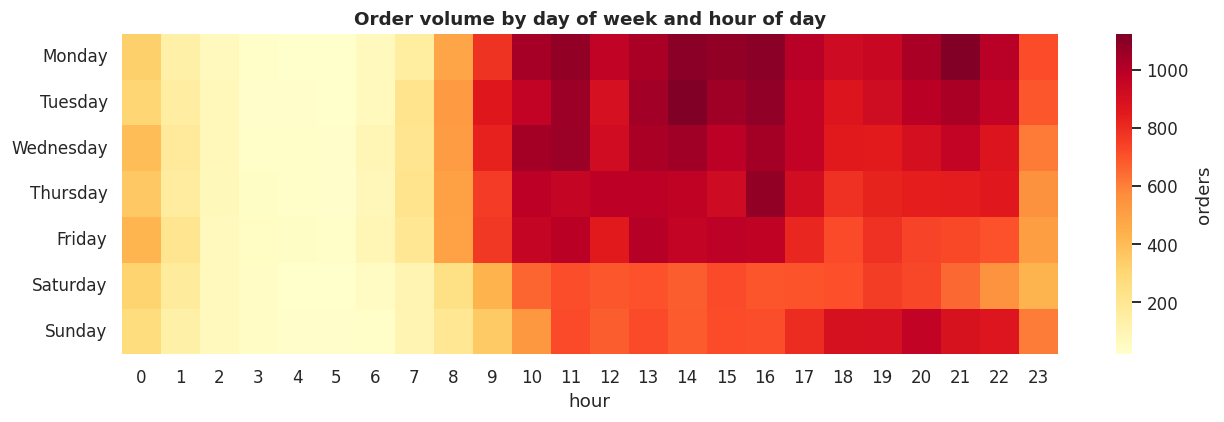

In [74]:
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heat = (order.groupby(["purchase_dow", "purchase_hour"]).size()
        .reset_index(name="n").pivot(index="purchase_dow", columns="purchase_hour", values="n")
        .reindex(dow_order))
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heat, cmap="YlOrRd", ax=ax, cbar_kws={"label": "orders"})
ax.set_title("Order volume by day of week and hour of day")
ax.set_xlabel("hour"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

Buying concentrates on weekday business hours with an afternoon peak — useful for capacity planning, but (as section 5 shows) purchase timing barely moves late-delivery rate.

## 5. Delivery performance

Restricting to delivered orders, we decompose the lead time, measure lateness against Olist's own
estimate, and show the strong geographic gradient.

Delivered orders: 96,478  (97.0% of all orders)
Late vs estimate: 6.8%  |  early: 91.9%
days vs estimate — median -12 (neg = early); only 2.4% are >30d early, 0.4% >30d late (range -147 to 188)
mean    12.10
50%     10.00
max    209.00


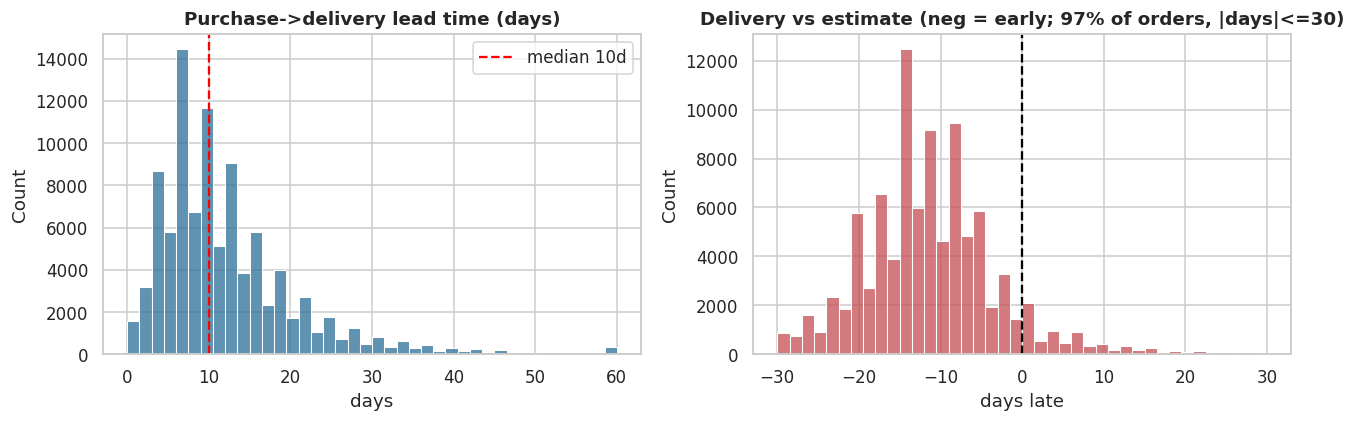

In [41]:
'''
delivery days = order delivered to customer date - purchase date
estimated days = estimated delivery date - purchase date
days late = order delivered to customer date - estimated delivery date
--> +ve = delivered late
--> -ve = delivered early
'''

d = delivered.dropna(subset=["delivery_days"]).copy()
print(f"Delivered orders: {len(delivered):,}  ({len(delivered)/len(order)*100:.1f}% of all orders)")
print(f"Late vs estimate: {d.is_late.mean()*100:.1f}%  |  early: {(d.days_late<0).mean()*100:.1f}%")
print(f"days vs estimate — median {d.days_late.median():.0f} (neg = early); "
      f"only {(d.days_late<-30).mean()*100:.1f}% are >30d early, {(d.days_late>30).mean()*100:.1f}% >30d late "
      f"(range {int(d.days_late.min())} to {int(d.days_late.max())})")
print(d["delivery_days"].describe()[["mean","50%","max"]].round(1).to_string())

### Chart 1 - Purchase date vs Actual delivery date (How many days did customers actually wait?)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(d.delivery_days.clip(0, 60), bins=40, ax=ax[0], color="#2A6F97")
ax[0].axvline(d.delivery_days.median(), color="red", ls="--",
              label=f"median {d.delivery_days.median():.0f}d"); ax[0].legend()
ax[0].set_title("Purchase->delivery lead time (days)"); ax[0].set_xlabel("days")

### Chart 2 - Actual delivery vs estimate delivery
# Show only the +/-30d window, EXCLUDING the thin tails (not clipping them onto the edge bins,
# which would create a misleading spike). ~2-3% of orders fall outside this range.
mid = d.days_late[d.days_late.between(-30, 30)]
sns.histplot(mid, bins=40, ax=ax[1], color="#C44E52")
ax[1].axvline(0, color="black", ls="--")
ax[1].set_title("Delivery vs estimate (neg = early; %.0f%% of orders, |days|<=30)" % (len(mid)/len(d)*100))
ax[1].set_xlabel("days late")
plt.tight_layout(); plt.show()

**Insights:** 97.0% of orders were delivered, with a median delivery time of 10 days. Only 6.8% were delivered late, while 91.9% arrived earlier than estimated. Early deliveries are concentrated around 10–15 days ahead of the estimated date, resulting in a median of 12 days early. This may suggest that estimated delivery dates are generally conservative. Actual delivery times are right-skewed due to a small number of unusually long deliveries, while extreme early deliveries form only a thin ~2–3% tail.

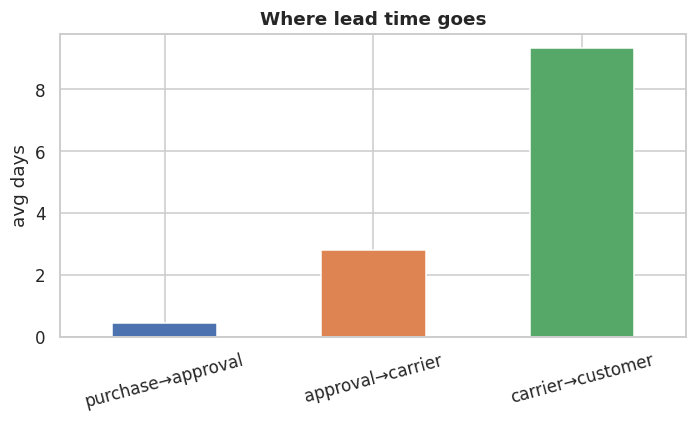

to_approval       0.43
to_carrier        2.80
carrier_to_cust   9.33


In [42]:
# lead-time decomposition into the three operational stages
dd = delivered.copy()
dd["to_approval"] = (dd.order_approved_at - dd.order_purchase_timestamp).dt.total_seconds()/86400
dd["to_carrier"] = (dd.order_delivered_carrier_date - dd.order_approved_at).dt.total_seconds()/86400
dd["carrier_to_cust"] = (dd.order_delivered_customer_date
                         - dd.order_delivered_carrier_date).dt.total_seconds()/86400
stages = dd[["to_approval","to_carrier","carrier_to_cust"]].mean()
fig, ax = plt.subplots(figsize=(6.5, 4))
stages.plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452","#55A868"])
ax.set_xticklabels(["purchase→approval","approval→carrier","carrier→customer"], rotation=15)
ax.set_ylabel("avg days"); ax.set_title("Where lead time goes")
plt.tight_layout(); plt.show()
print(stages.round(2).to_string())

**Insights:** Most of the wait is the **carrier→customer leg** (~9 days), not seller handling — the delay is logistics, not approval.

In [45]:
state = (d.groupby("customer_state")
         .agg(orders=("order_id","count"), median_days=("delivery_days","median"),
              late_rate=("is_late","mean")).sort_values("median_days", ascending=False))
state["late_rate"] = (state.late_rate*100).round(1)
state

,orders,median_days,late_rate
customer_state,,,
AM,145,25.00,2.80
RR,41,25.00,12.20
AP,67,24.00,3.00
AL,397,22.00,21.40
PA,946,21.00,11.20
MA,717,19.00,17.40
AC,80,18.00,3.80
PB,517,18.00,10.40
SE,335,18.00,15.20


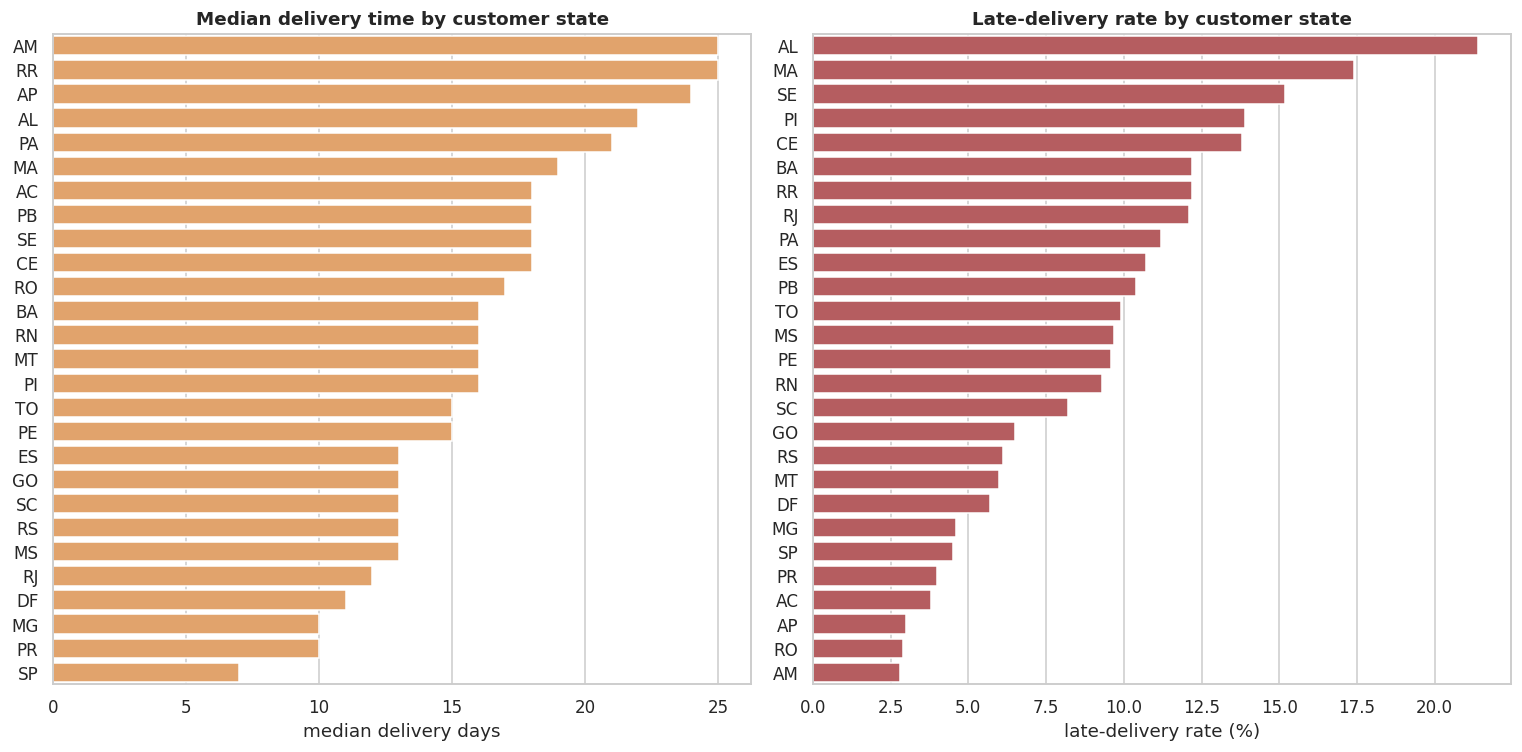

Fastest/slowest states by median transit time:
customer_state
AM   25.00
RR   25.00
AP   24.00
customer_state
MG   10.00
PR   10.00
SP    7.00

Highest/lowest late-delivery rate by state:
customer_state
AL   21.40
MA   17.40
SE   15.20
customer_state
AP   3.00
RO   2.90
AM   2.80

Sample sizes for the slowest-by-median states (median is noisier with fewer orders):
customer_state
AM    145
RR     41
AP     67


In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
sns.barplot(x=state.median_days, y=state.index, ax=ax[0], color="#F4A259")
ax[0].set_xlabel("median delivery days"); ax[0].set_ylabel("")
ax[0].set_title("Median delivery time by customer state")

state_by_late = state.sort_values("late_rate", ascending=False)
sns.barplot(x=state_by_late.late_rate, y=state_by_late.index, ax=ax[1], color="#C44E52")
ax[1].set_xlabel("late-delivery rate (%)"); ax[1].set_ylabel("")
ax[1].set_title("Late-delivery rate by customer state")
plt.tight_layout(); plt.show()

print("Fastest/slowest states by median transit time:")
print(state.median_days.head(3).to_string()); print(state.median_days.tail(3).to_string())
print("\nHighest/lowest late-delivery rate by state:")
print(state_by_late.late_rate.head(3).to_string()); print(state_by_late.late_rate.tail(3).to_string())
print("\nSample sizes for the slowest-by-median states (median is noisier with fewer orders):")
print(state.loc[["AM","RR","AP"], "orders"].to_string())

**Insights:** A strong geographic gradient: SP (where most sellers sit) gets orders in ~7 days with <6% late; remote northern states (e.g. RR, AP, AM) wait 2–3× as long. Distance is the dominant driver of both delivery time and freight.

**Longest transit time and highest late-delivery rate are not the same states** — this is worth flagging explicitly since it matters for the classification target. AL has only a mid-range median delivery time (~22 days) but by far the **highest late rate in the dataset (21.4%)**, followed by MA (17.4%) and SE (15.2%) — none of which are among the slowest-by-median states. Meanwhile AM, RR, and AP — the slowest by raw transit time — actually have among the *lowest* late rates (2.8-4%), suggesting Olist sets a more generous estimated-delivery window for the known-remote states.

**Practical implication:** Distance remains the dominant driver of delivery time and freight overall, but late-rate is also a metric that needs to be considered. Also, late_rate is evidently shaped by more than distance alone, likely including how conservatively Olist sets the estimate per region.

## 6. Customer, seller and product distributions

All three actor tables are highly skewed — a small share of customers, sellers and categories
account for most of the activity, and each skew rules a candidate target in or out. We look at
each in turn: **6.1** customer repeat behaviour and retention, **6.2** seller revenue
concentration and the supply/demand geography gap, **6.3** product categories, price and physical
size, **6.4** payments. Where a distribution matters for the freight story of Section 7, we
quantify the link here rather than leaving it to the eye.


### 6.1 Customers — repeat behaviour

Distinct customers: 96,096 | repeat (>1 order): 3.12% | they carry only 5.8% of revenue
Days between 1st and 2nd order (repeat customers) — median 27, p25 0, p75 123
Returning orders as a share of monthly volume: 2.0% overall, peak month 3.1%
Order demand by state — top 3: SP 42%, RJ 13%, MG 12% | remaining 24 states share 33%


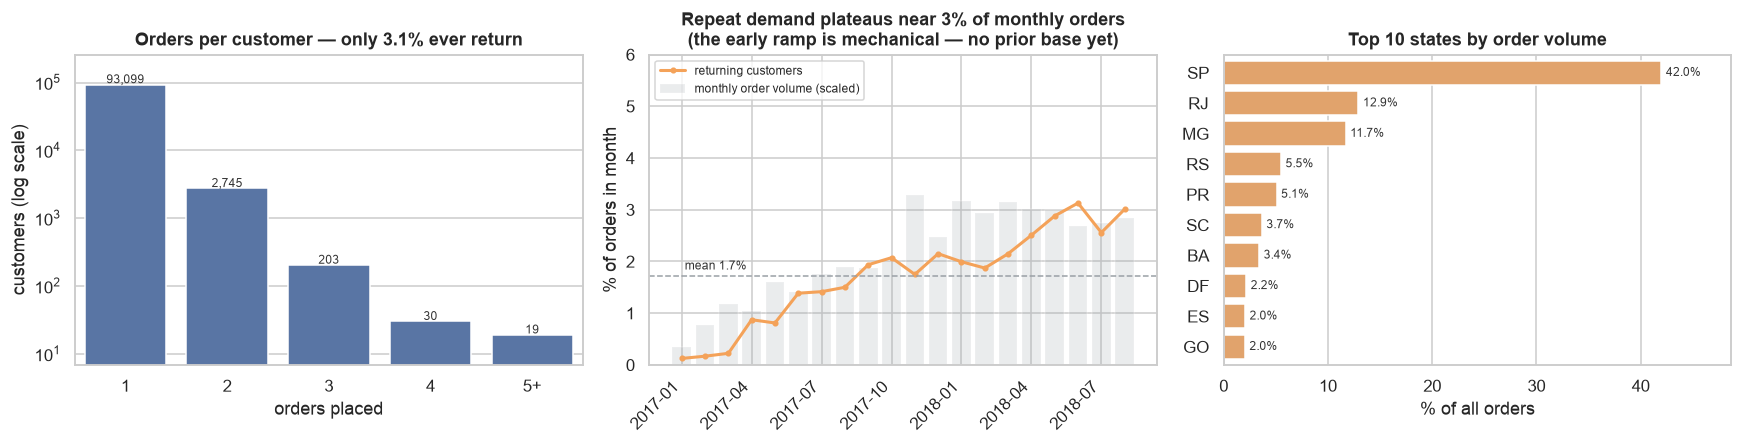

In [13]:
# ---- Shared look-and-feel for section 6 ----
PAL = {"cust": "#4C72B0", "sell": "#BC4749", "prod": "#588157",
       "accent": "#F4A259", "alt": "#8172B2", "grey": "#9AA0A6"}

def thousands(ax, axis="x"):
    """Human-readable tick labels (12,345 -> 12.3k) on the given axis."""
    fmt = mticker.FuncFormatter(
        lambda v, _: f"{v/1e6:.1f}M" if abs(v) >= 1e6 else (f"{v/1e3:.0f}k" if abs(v) >= 1e3 else f"{v:,.0f}"))
    (ax.xaxis if axis == "x" else ax.yaxis).set_major_formatter(fmt)

def label_bars(ax, fmt="{:,.0f}", horizontal=True, pad=3):
    """Write the value at the end of every bar so the reader never guesses."""
    for p in ax.patches:
        v = p.get_width() if horizontal else p.get_height()
        if not np.isfinite(v) or v == 0:
            continue
        xy = ((v, p.get_y() + p.get_height()/2) if horizontal
              else (p.get_x() + p.get_width()/2, v))
        ax.annotate(fmt.format(v), xy, xytext=(pad, 0) if horizontal else (0, pad),
                    textcoords="offset points", va="center",
                    ha="left" if horizontal else "center", fontsize=8, color="#333")
    ax.margins(x=0.16 if horizontal else 0.02, y=0.02 if horizontal else 0.12)

# ---- Customers: repeat behaviour, retention over time, geography ----
cust_orders = (order.groupby("customer_unique_id")
               .agg(orders=("order_id", "nunique"),
                    spend=("order_total", "sum"),
                    first_month=("purchase_month", "min")))
repeat_rate = (cust_orders.orders > 1).mean()*100
repeat_rev_share = cust_orders.loc[cust_orders.orders > 1, "spend"].sum()/cust_orders.spend.sum()*100
print(f"Distinct customers: {len(cust_orders):,} | repeat (>1 order): {repeat_rate:.2f}% "
      f"| they carry only {repeat_rev_share:.1f}% of revenue")

# gap between a repeat customer's first two orders — is there any re-purchase rhythm?
rep = order[order.customer_unique_id.isin(cust_orders.index[cust_orders.orders > 1])]
gap = (rep.sort_values("order_purchase_timestamp")
       .groupby("customer_unique_id")["order_purchase_timestamp"]
       .apply(lambda s: (s.iloc[1] - s.iloc[0]).days))
print(f"Days between 1st and 2nd order (repeat customers) — median {gap.median():.0f}, "
      f"p25 {gap.quantile(.25):.0f}, p75 {gap.quantile(.75):.0f}")

# new vs returning demand each month
o = order.dropna(subset=["purchase_month"]).copy()
o["is_returning"] = o.purchase_month > o.customer_unique_id.map(cust_orders.first_month)
mix = (o.groupby(["purchase_month", "is_returning"]).size().unstack(fill_value=0)
       .rename(columns={False: "new", True: "returning"}))
mix = mix.loc["2017-01":"2018-08"]
print(f"Returning orders as a share of monthly volume: "
      f"{mix['returning'].sum()/mix.sum().sum()*100:.1f}% overall, "
      f"peak month {mix['returning'].div(mix.sum(axis=1)).max()*100:.1f}%")

cs = order.customer_state.value_counts()
print("Order demand by state — top 3: " +
      ", ".join(f"{s} {n/len(order)*100:.0f}%" for s, n in cs.head(3).items()) +
      f" | remaining {len(cs)-3} states share {(1-cs.head(3).sum()/len(order))*100:.0f}%")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

od = cust_orders.orders.value_counts().sort_index()
od = pd.concat([od[od.index <= 4], pd.Series({5: od[od.index >= 5].sum()})])
sns.barplot(x=[str(i) if i < 5 else "5+" for i in od.index], y=od.values,
            ax=ax[0], color=PAL["cust"])
label_bars(ax[0], "{:,.0f}", horizontal=False)
ax[0].set_yscale("log")
ax[0].set_title(f"Orders per customer — only {repeat_rate:.1f}% ever return")
ax[0].set_xlabel("orders placed"); ax[0].set_ylabel("customers (log scale)")

ret_share = mix["returning"]/mix.sum(axis=1)*100
xs = np.arange(len(mix))
ax[1].bar(xs, mix.sum(axis=1)/mix.sum(axis=1).max()*ret_share.max()*1.05,
          color=PAL["grey"], alpha=.20, label="monthly order volume (scaled)")
ax[1].plot(xs, ret_share.values, color=PAL["accent"], lw=2, marker="o", ms=3,
           label="returning customers")
ax[1].axhline(ret_share.mean(), color=PAL["grey"], ls="--", lw=1)
ax[1].annotate(f"mean {ret_share.mean():.1f}%", (0, ret_share.mean()), xytext=(2, 4),
               textcoords="offset points", fontsize=8, color="#333")
ax[1].set_xticks(xs[::3]); ax[1].set_xticklabels(mix.index[::3], rotation=45, ha="right")
ax[1].set_ylim(0, max(6, ret_share.max()*1.35)); ax[1].set_ylabel("% of orders in month")
ax[1].set_title("Repeat demand plateaus near 3% of monthly orders\n(the early ramp is mechanical — no prior base yet)")
ax[1].legend(loc="upper left", fontsize=8)

top = cs.head(10)
sns.barplot(x=(top/len(order)*100).values, y=top.index, ax=ax[2], color=PAL["accent"])
label_bars(ax[2], "{:.1f}%")
ax[2].set_ylabel("")
ax[2].set_title("Top 10 states by order volume"); ax[2].set_xlabel("% of all orders")
plt.tight_layout(); plt.show()


Repeat purchasing is essentially absent: only 3.1% of customers ever place a second order,
and those repeaters carry just 5.8% of revenue. Hence, a repeat-purchase or customer-lifetime-value
target would be a rare-event problem on a very thin signal, and we do not pursue it. The middle
panel shows this is not a maturity artefact: the returning share climbs only while the platform
has no prior base to return to, then plateaus near 3% even as monthly volume triples. When
customers do come back, they come back quickly (median 27 days between first and second order),
which points to a one-off replenishment rather than a habit.

Demand is also geographically lopsided (SP 42%, RJ 13%, MG 12%), with the remaining 24 states
sharing 33%. That is the same geography behind the delivery-time gradient in Section 5. Section 6.2
shows it matters as supply is even more concentrated than demand.

### 6.2 Sellers — revenue concentration and geography


Sellers: 3,095 | top 543 (18%) make 80% of item revenue
Cumulative revenue share — top 1% of sellers: 26%, top 5% of sellers: 53%, top 10% of sellers: 67%, top 20% of sellers: 83%
Item lines per seller — median 8, p90 80, max 2,033; 58% of sellers ship 10 lines or fewer
Item lines shipped across state lines: 64%  (median 654 km, freight R$18.25) vs within-state (median 96 km, R$11.99)


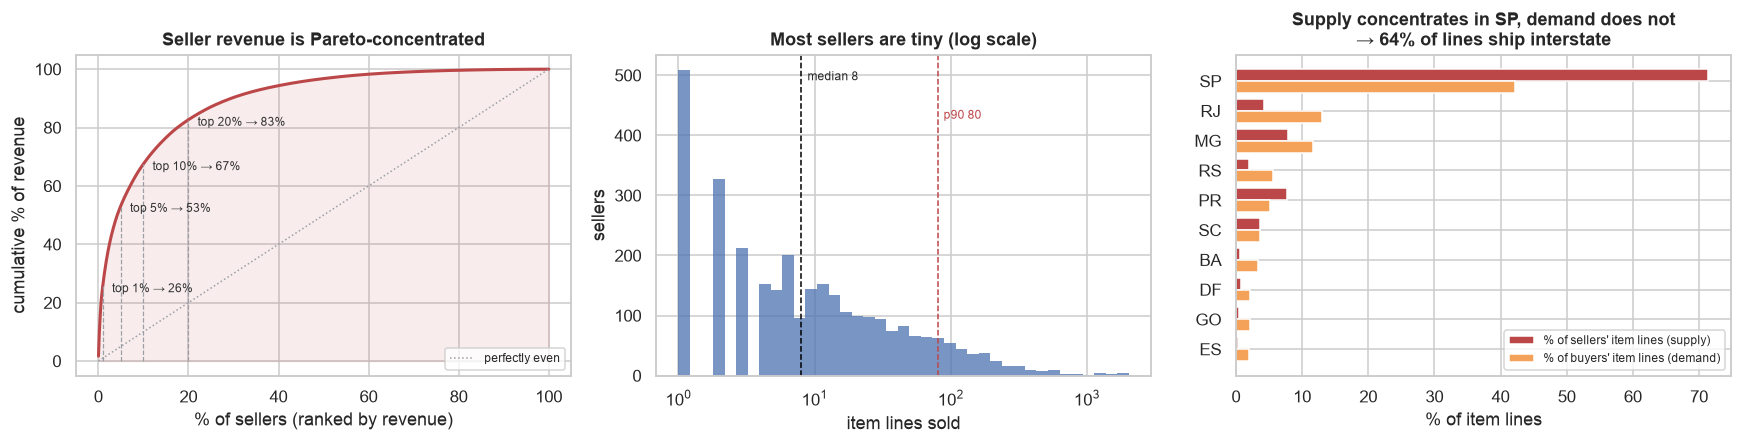

In [14]:
# ---- Sellers: Pareto concentration, size spread, and the supply-demand geography gap ----
seller_rev = item.groupby("seller_id")["price"].sum().sort_values(ascending=False)
cum = seller_rev.cumsum()/seller_rev.sum()
top_share = (cum <= 0.8).sum()
qs = {p: cum.iloc[int(len(cum)*p/100)-1]*100 for p in (1, 5, 10, 20)}
print(f"Sellers: {seller_rev.size:,} | top {top_share:,} ({top_share/seller_rev.size*100:.0f}%) "
      f"make 80% of item revenue")
print("Cumulative revenue share — " + ", ".join(f"top {p}% of sellers: {v:.0f}%" for p, v in qs.items()))

seller_items = item.groupby("seller_id")["order_item_id"].count()
print(f"Item lines per seller — median {seller_items.median():.0f}, "
      f"p90 {seller_items.quantile(.9):.0f}, max {seller_items.max():,}; "
      f"{(seller_items <= 10).mean()*100:.0f}% of sellers ship 10 lines or fewer")

# where supply sits vs where demand sits, and what that costs in freight
sup = item.seller_state.value_counts(normalize=True)*100
dem = item.customer_state.value_counts(normalize=True)*100
geo_gap = pd.DataFrame({"supply": sup, "demand": dem}).fillna(0)
geo_gap = geo_gap.loc[geo_gap.sum(axis=1).sort_values(ascending=False).head(10).index]

x = item.dropna(subset=["seller_state", "customer_state"]).copy()
x["interstate"] = x.seller_state != x.customer_state
inter = x.groupby("interstate").agg(share=("order_id", "size"),
                                    med_freight=("freight_value", "median"),
                                    med_dist=("distance_km", "median"),
                                    med_ratio=("freight_ratio", "median"))
inter["share"] = inter["share"]/len(x)*100
print(f"Item lines shipped across state lines: {inter.loc[True, 'share']:.0f}%  "
      f"(median {inter.loc[True,'med_dist']:.0f} km, freight R${inter.loc[True,'med_freight']:.2f}) "
      f"vs within-state (median {inter.loc[False,'med_dist']:.0f} km, R${inter.loc[False,'med_freight']:.2f})")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

pct = np.arange(1, len(cum)+1)/len(cum)*100
ax[0].plot(pct, cum.values*100, color=PAL["sell"], lw=2)
ax[0].fill_between(pct, 0, cum.values*100, color=PAL["sell"], alpha=.10)
ax[0].plot([0, 100], [0, 100], color=PAL["grey"], ls=":", lw=1, label="perfectly even")
for p, v in qs.items():
    ax[0].plot([p, p], [0, v], color=PAL["grey"], ls="--", lw=.8)
    ax[0].annotate(f"top {p}% → {v:.0f}%", (p, v), xytext=(6, -4),
                   textcoords="offset points", fontsize=8, color="#333")
ax[0].set_xlabel("% of sellers (ranked by revenue)"); ax[0].set_ylabel("cumulative % of revenue")
ax[0].set_title("Seller revenue is Pareto-concentrated"); ax[0].legend(loc="lower right", fontsize=8)

sns.histplot(seller_items, bins=np.logspace(0, np.log10(seller_items.max()), 40),
             ax=ax[1], color=PAL["cust"])
ax[1].set_xscale("log")
for q, c in [(seller_items.median(), "black"), (seller_items.quantile(.9), PAL["sell"])]:
    ax[1].axvline(q, color=c, ls="--", lw=1)
ax[1].annotate(f"median {seller_items.median():.0f}", (seller_items.median(), ax[1].get_ylim()[1]*.92),
               xytext=(4, 0), textcoords="offset points", fontsize=8)
ax[1].annotate(f"p90 {seller_items.quantile(.9):.0f}", (seller_items.quantile(.9), ax[1].get_ylim()[1]*.80),
               xytext=(4, 0), textcoords="offset points", fontsize=8, color=PAL["sell"])
ax[1].set_title("Most sellers are tiny (log scale)"); ax[1].set_xlabel("item lines sold"); ax[1].set_ylabel("sellers")

gg = geo_gap.sort_values("demand")
ypos = np.arange(len(gg))
ax[2].barh(ypos+.2, gg.supply, height=.4, color=PAL["sell"], label="% of sellers' item lines (supply)")
ax[2].barh(ypos-.2, gg.demand, height=.4, color=PAL["accent"], label="% of buyers' item lines (demand)")
ax[2].set_yticks(ypos); ax[2].set_yticklabels(gg.index)
ax[2].set_xlabel("% of item lines"); ax[2].legend(fontsize=8, loc="lower right")
ax[2].set_title(f"Supply concentrates in SP, demand does not\n→ {inter.loc[True,'share']:.0f}% of lines ship interstate")
plt.tight_layout(); plt.show()


Seller revenue is sharply Pareto-concentrated where the top 1% of sellers take 26% of item revenue,
the top 10% take 67%, and 18% of sellers cover 80%. That keeps a seller-level target technically
open, but the size histogram closes it again as the median seller ships only 8 item lines and
58% ship 10 or fewer, far too thin to model individually.

The third panel is the one that feeds Section 7. Supply and demand do not sit in the same
places: São Paulo hosts ~71% of the item lines sold but only ~42% of the buyers, while RJ, MG, BA
and the rest buy far more than they sell. The consequence is structural, 64% of item lines ship
across a state line, at a median 654 km vs 96 km within-state and a median freight of
R$18.25 vs R$11.99. Distance is not an edge case in this marketplace, it is the default, which
is why freight is worth modelling.

### 6.3 Products — categories, price and physical size


Distinct categories: 74 | top 10 by volume = 64% of item lines, top 10 by revenue = 62% of revenue
Cheapest categories carry the heaviest freight burden:
                 lines  med_price  med_freight  med_ratio
category                                                 
electronics       2767      21.90        15.10       0.62
telephony         4545      29.99        15.10       0.43
drinks             379      47.49        15.10       0.32
home_appliances    771      47.59        16.11       0.31
garden_tools      4347      59.90        17.67       0.29
Corr(median price, median freight ratio) across categories: -0.86
Spearman(weight, price) at item level: 0.51 | weight p50 0.70 kg, p99 18.2 kg | price p50 R$75, p99 R$890


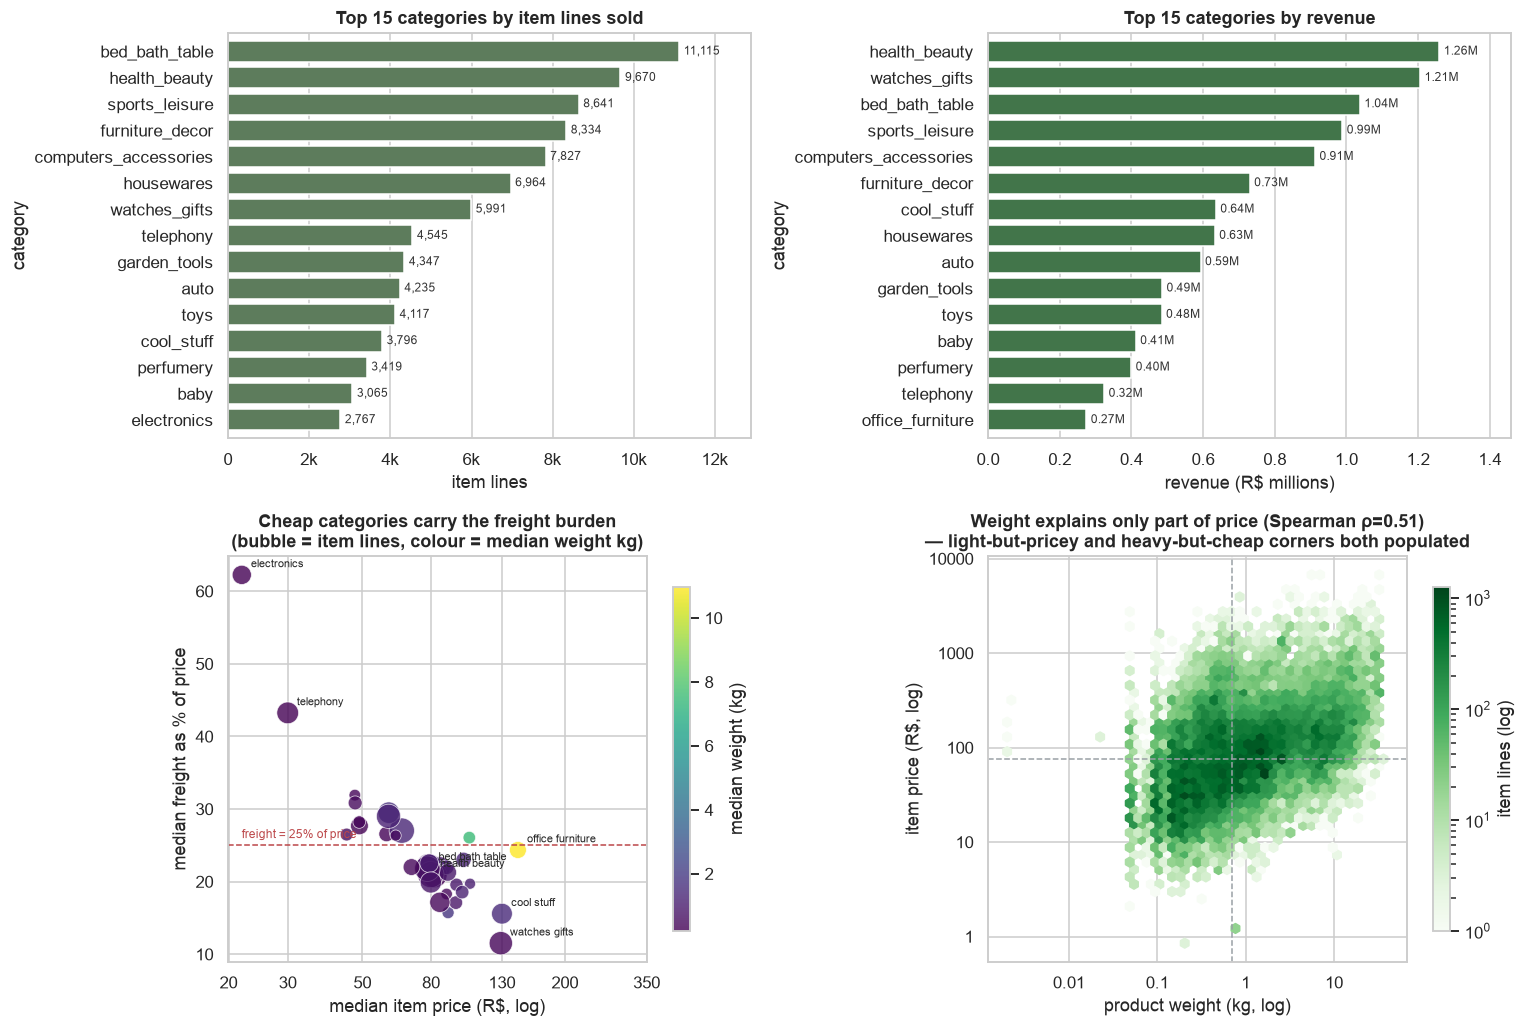

In [15]:
# ---- Products: category volume vs revenue, and the price/freight-burden preview ----
cat = (item.groupby("category")
       .agg(lines=("order_item_id", "count"), revenue=("price", "sum"),
            med_price=("price", "median"), med_freight=("freight_value", "median"),
            med_ratio=("freight_ratio", "median"), med_weight=("weight_kg", "median")))
cat_counts = cat.lines.sort_values(ascending=False).head(15)
cat_revenue = cat.revenue.sort_values(ascending=False).head(15)
print(f"Distinct categories: {len(cat)} | top 10 by volume = "
      f"{cat.lines.sort_values(ascending=False).head(10).sum()/cat.lines.sum()*100:.0f}% of item lines, "
      f"top 10 by revenue = {cat.revenue.sort_values(ascending=False).head(10).sum()/cat.revenue.sum()*100:.0f}% of revenue")

big = cat[cat.lines >= 300].copy()
print("Cheapest categories carry the heaviest freight burden:")
print(big.sort_values("med_ratio", ascending=False)
      .head(5)[["lines", "med_price", "med_freight", "med_ratio"]].round(2).to_string())
print("Corr(median price, median freight ratio) across categories: "
      f"{np.corrcoef(np.log(big.med_price), big.med_ratio)[0,1]:.2f}")

fig, ax = plt.subplots(2, 2, figsize=(14, 9.5))

sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax[0, 0], color=PAL["prod"])
label_bars(ax[0, 0], "{:,.0f}"); thousands(ax[0, 0])
ax[0, 0].set_title("Top 15 categories by item lines sold"); ax[0, 0].set_xlabel("item lines")

sns.barplot(x=cat_revenue.values/1e6, y=cat_revenue.index, ax=ax[0, 1], color="#3A7D44")
label_bars(ax[0, 1], "{:.2f}M")
ax[0, 1].set_title("Top 15 categories by revenue"); ax[0, 1].set_xlabel("revenue (R$ millions)")

sc = ax[1, 0].scatter(big.med_price, big.med_ratio*100, s=np.sqrt(big.lines)*3,
                      c=big.med_weight, cmap="viridis", alpha=.8, edgecolor="white", lw=.5)
ax[1, 0].set_xscale("log")
ax[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax[1, 0].xaxis.set_minor_formatter(mticker.NullFormatter())
ax[1, 0].set_xticks([20, 30, 50, 80, 130, 200, 350])
ax[1, 0].axhline(25, color=PAL["sell"], ls="--", lw=1)
ax[1, 0].annotate("freight = 25% of price", (big.med_price.min(), 26), fontsize=8, color=PAL["sell"])
for name in dict.fromkeys(list(big.med_ratio.nlargest(2).index) + list(big.lines.nlargest(2).index)
                          + list(big.med_price.nlargest(2).index) + list(big.med_ratio.nsmallest(1).index)):
    r = big.loc[name]
    ax[1, 0].annotate(name.replace("_", " ")[:20], (r.med_price, r.med_ratio*100),
                      xytext=(6, 5), textcoords="offset points", fontsize=7.5)
ax[1, 0].set_xlabel("median item price (R$, log)"); ax[1, 0].set_ylabel("median freight as % of price")
ax[1, 0].set_title("Cheap categories carry the freight burden\n(bubble = item lines, colour = median weight kg)")
plt.colorbar(sc, ax=ax[1, 0], label="median weight (kg)", shrink=.85)

# price and weight are near-independent: freight follows weight, revenue follows price
pw = item.dropna(subset=["weight_kg", "price"])
pw = pw[(pw.weight_kg > 0) & (pw.price > 0)]
hb = ax[1, 1].hexbin(pw.weight_kg, pw.price, xscale="log", yscale="log",
                     gridsize=45, cmap="Greens", mincnt=1, bins="log")
ax[1, 1].axvline(pw.weight_kg.median(), color=PAL["grey"], ls="--", lw=1)
ax[1, 1].axhline(pw.price.median(), color=PAL["grey"], ls="--", lw=1)
rho = pw[["weight_kg", "price"]].corr(method="spearman").iloc[0, 1]
ax[1, 1].set_title(f"Weight explains only part of price (Spearman ρ={rho:.2f})\n"
                   "— light-but-pricey and heavy-but-cheap corners both populated")
ax[1, 1].set_xlabel("product weight (kg, log)"); ax[1, 1].set_ylabel("item price (R$, log)")
for a in (ax[1, 1].xaxis, ax[1, 1].yaxis):
    a.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
plt.colorbar(hb, ax=ax[1, 1], label="item lines (log)", shrink=.85)
print(f"Spearman(weight, price) at item level: {rho:.2f} | "
      f"weight p50 {pw.weight_kg.median():.2f} kg, p99 {pw.weight_kg.quantile(.99):.1f} kg | "
      f"price p50 R${pw.price.median():.0f}, p99 R${pw.price.quantile(.99):.0f}")
plt.tight_layout(); plt.show()


Item volume is concentrated in a handful of categories (bed/bath/table, health & beauty, sports),
with the top 10 categories carrying 64% of item lines and 62% of revenue** out of 74. The revenue
leaderboard re-ranks them: higher-priced categories such as watches/gifts and computers punch well
above their item-count weight.

The bottom-left panel makes the Section 7 argument concrete at category level. Freight is roughly
flat in absolute terms (median category freight R$16), so as a share of price it collapses
as price rises: correlation between (log) median category price and median freight burden is
−0.86. Electronics pays a R$15.10 median freight on a R$21.90 median item, 62% of the item's
price, while watches/gifts pays a similar absolute freight on items 6× dearer and barely feels
it. Over a third of the 35 categories with 300+ lines sit above the 25%-of-price line.

The hexbin explains why this is not simply "cheap things are light": weight and price are only
moderately related (Spearman ρ = 0.51), and both the light-but-expensive and heavy-but-cheap
corners are well populated. Freight is priced off weight and distance, revenue off price — the gap
between those two is precisely the freight-burden problem.

### 6.4 Payments


Payment mix — credit_card 73.9%, boleto 19.0%, voucher 5.6%, debit_card 1.5%
Credit-card orders paid in instalments (>1): 67% | median 3, p90 8
Median order value rises from R$79 at 1 instalment to R$238 at 10 — instalments track basket size, not distress


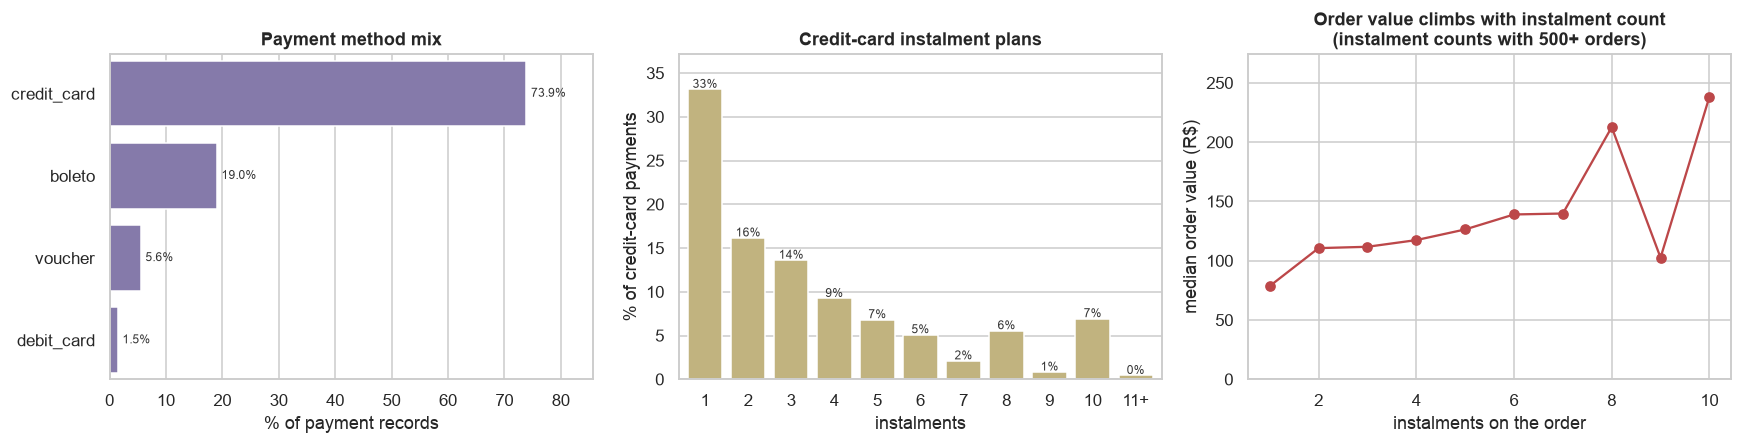

In [16]:
# ---- Payments: method mix, instalment behaviour, and its link to order value ----
pay = t["payments"]
pv = pay.payment_type.value_counts(normalize=True)*100
pv = pv[pv >= 0.1]
card = pay[(pay.payment_type == "credit_card") & (pay.payment_installments > 0)]
print("Payment mix — " + ", ".join(f"{k} {v:.1f}%" for k, v in pv.head(4).items()))
print(f"Credit-card orders paid in instalments (>1): {(card.payment_installments > 1).mean()*100:.0f}%"
      f" | median {card.payment_installments.median():.0f}, p90 {card.payment_installments.quantile(.9):.0f}")
inst_val = order.dropna(subset=["max_installments", "order_total"])
inst_val = inst_val[inst_val.max_installments.between(1, 12)]
by_inst = inst_val.groupby("max_installments").agg(med=("order_total", "median"),
                                                   n=("order_id", "size"))
med_by_inst = by_inst.loc[by_inst.n >= 500, "med"]   # drop instalment counts too thin to read
print(f"Median order value rises from R${med_by_inst.iloc[0]:.0f} at {med_by_inst.index[0]:.0f} instalment "
      f"to R${med_by_inst.iloc[-1]:.0f} at {med_by_inst.index[-1]:.0f} — instalments track basket size, not distress")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.barplot(x=pv.values, y=pv.index, ax=ax[0], color=PAL["alt"])
label_bars(ax[0], "{:.1f}%")
ax[0].set_ylabel("")
ax[0].set_title("Payment method mix"); ax[0].set_xlabel("% of payment records")

ic = card.payment_installments.clip(upper=11).value_counts().sort_index()
ic.index = [str(int(i)) if i < 11 else "11+" for i in ic.index]
sns.barplot(x=ic.index, y=(ic/ic.sum()*100).values, ax=ax[1], color="#CCB974")
label_bars(ax[1], "{:.0f}%", horizontal=False)
ax[1].set_title("Credit-card instalment plans"); ax[1].set_xlabel("instalments")
ax[1].set_ylabel("% of credit-card payments")

ax[2].plot(med_by_inst.index, med_by_inst.values, marker="o", color=PAL["sell"])
ax[2].set_ylim(0, med_by_inst.max()*1.15)
ax[2].set_title("Order value climbs with instalment count\n(instalment counts with 500+ orders)")
ax[2].set_xlabel("instalments on the order"); ax[2].set_ylabel("median order value (R$)")
plt.tight_layout(); plt.show()


Payments are dominated by credit cards (74% of payment records) and boleto (19%), and
67% of card orders are split into instalments (median 3). Instalment count tracks basket size
rather than distress where median order value climbs from R$79 on a single instalment to R$238 at ten. Hence, instalments are usable as a proxy for order value, not as a risk signal.

In conclusion, from Section 6 we see that all three actor tables are heavily skewed, and the skews point away
from customer- and seller-centred targets: repeat purchasing is a 3% rare event worth 5.8% of
revenue, and the Pareto curve sits on top of a long tail of sellers with a handful of lines each.
Reviews (Section 8) are similarly awkward — bimodal, and with majority-empty text (Section 2) they
are usable only as a 1–5 score.

What Section 6 does hand forward is the freight case: supply concentrated in SP against dispersed
demand forces 64% of lines interstate, freight is near-flat in reais while prices span three
orders of magnitude, and the resulting burden falls hardest on the cheapest categories (−0.86
price-vs-burden correlation). That is the densest, most actionable signal in the dataset, and we
pursue it in Sections 7–9.


## 7. Freight economics — the central theme

Freight (`freight_value`) is the shipping fee charged on each item line, in Brazilian Reais, and it is
the largest systematic cost in the data after the goods themselves. This section asks two plain
questions: **what drives freight**, and **how evenly does it fall** across items?

Shipping has three natural physical drivers — **weight** (heavier costs more to move), **size /
volume** (a bulky box takes van and warehouse space even when light), and **distance** (farther is
dearer). We also bring in the item **price**, not because price *causes* freight, but for two jobs:
to measure the *burden* freight places on the customer (`freight_ratio = freight / price`), and as a
contrast — if freight tracked price, shipping would behave like a tax on value; if it tracks the
parcel instead, it behaves like a genuine logistics cost. The charts that follow work through both —
first how big freight is, then what it is driven by.

Freight as % of item price  — median 23.1%, mean 32.1%
Share of items with freight > 25% of price: 46.0%
Freight as % of total GMV   — 14.2%


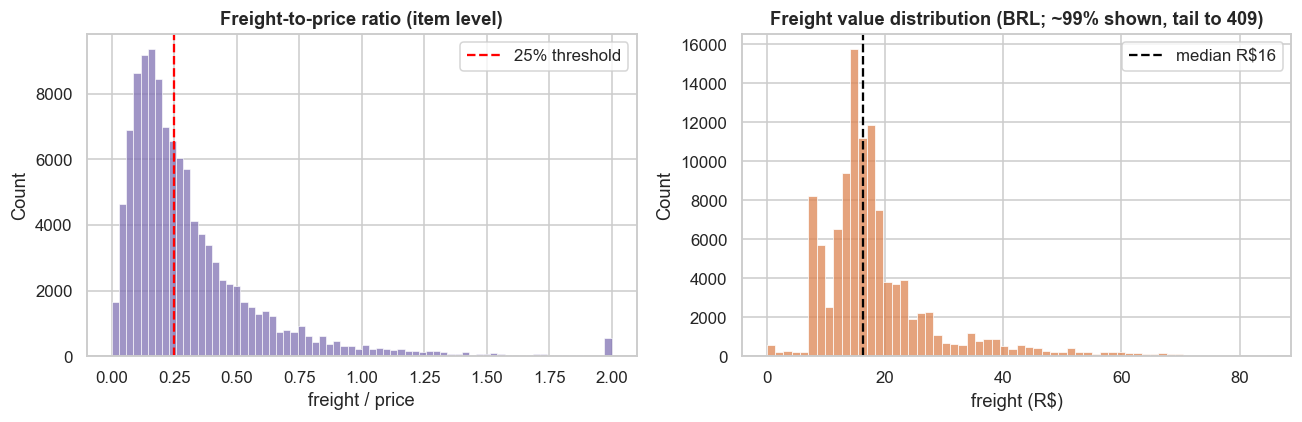

In [22]:
f = item.dropna(subset=["freight_ratio"]).copy()
f = f[(f.price > 0) & (f.freight_value >= 0)]
print("Freight as %% of item price  — median %.1f%%, mean %.1f%%"
      % (f.freight_ratio.median()*100, f.freight_ratio.mean()*100))
print("Share of items with freight > 25%% of price: %.1f%%" % ((f.freight_ratio > 0.25).mean()*100))
FREIGHT_GMV = item.freight_value.sum()/(item.freight_value.sum()+item.price.sum())*100
print("Freight as %% of total GMV   — %.1f%%" % FREIGHT_GMV)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(f.freight_ratio.clip(upper=2), bins=70, ax=ax[0], color="#8172B3")
ax[0].axvline(0.25, color="red", ls="--", label="25% threshold"); ax[0].legend()
ax[0].set_title("Freight-to-price ratio (item level)"); ax[0].set_xlabel("freight / price")
cap = f.freight_value.quantile(0.99)
sns.histplot(f.freight_value[f.freight_value <= cap], bins=60, ax=ax[1], color="#DD8452")
ax[1].axvline(f.freight_value.median(), color="black", ls="--",
              label="median R$%.0f" % f.freight_value.median()); ax[1].legend()
ax[1].set_title("Freight value distribution (BRL; ~99%% shown, tail to %d)" % f.freight_value.max())
ax[1].set_xlabel("freight (R$)")
plt.tight_layout(); plt.show()

**Freight is a large, right-skewed charge.** It is about **14% of GMV** — *Gross Merchandise
Value*, the total value of goods sold through the marketplace — and a median **23% of the item's own
price**, with **46%** of items paying more than a quarter of their price again in shipping. The
distribution clusters around **R$15–20** (median R$16) and tapers through R$30–60, with a thin tail
of heavy or long-haul shipments out to ~R$410 (about 1% sit above the R$80 view shown). Freight is
big enough, and common enough, to deserve study in its own right.

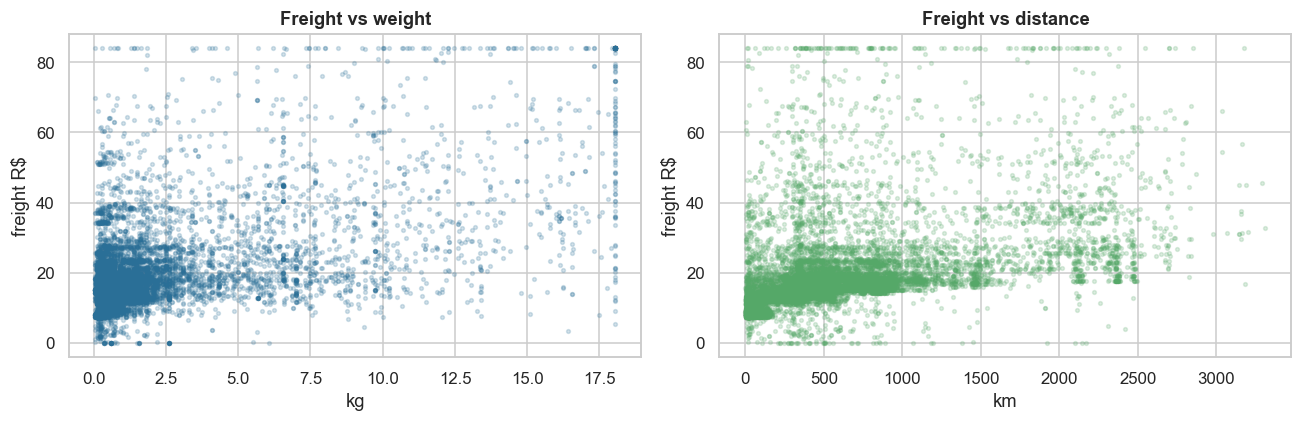

Pearson freight vs weight  : 0.612
Pearson freight vs volume  : 0.587
Pearson freight vs distance: 0.390
Pearson freight vs price   : 0.415


In [23]:
# freight vs the physical drivers
core = f.dropna(subset=["distance_km", "weight_kg", "volumetric_weight_kg"])
core = core[(core.weight_kg > 0)]
samp = core.sample(min(12000, len(core)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(samp.weight_kg.clip(upper=samp.weight_kg.quantile(.99)),
              samp.freight_value.clip(upper=samp.freight_value.quantile(.99)),
              s=6, alpha=0.2, color="#2A6F97")
ax[0].set_title("Freight vs weight"); ax[0].set_xlabel("kg"); ax[0].set_ylabel("freight R$")
ax[1].scatter(samp.distance_km, samp.freight_value.clip(upper=samp.freight_value.quantile(.99)),
              s=6, alpha=0.2, color="#55A868")
ax[1].set_title("Freight vs distance"); ax[1].set_xlabel("km"); ax[1].set_ylabel("freight R$")
plt.tight_layout(); plt.show()
print("Pearson freight vs weight  : %.3f" % core[["weight_kg","freight_value"]].corr().iloc[0,1])
print("Pearson freight vs volume  : %.3f" % core[["volumetric_weight_kg","freight_value"]].corr().iloc[0,1])
print("Pearson freight vs distance: %.3f" % core[["distance_km","freight_value"]].corr().iloc[0,1])
print("Pearson freight vs price   : %.3f" % core[["price","freight_value"]].corr().iloc[0,1])

**Freight is priced off the parcel, not the price.** It rises with weight and distance, and the
correlations confirm it: freight vs **weight ≈ 0.61**, vs **volumetric weight ≈ 0.59**, vs
**distance ≈ 0.39**, but only **≈ 0.41** vs price. The physical shipment explains freight; the item's
value barely does — the first sign that freight is a real cost, not a value-based markup.

> **Note — volumetric ("dimensional") weight.** We compute `volumetric_weight_kg = L × W × H
> (cm) / 5000`. The **5000** is a carrier convention, not a physical constant: DHL, FedEx and UPS use
> 5000 for most express parcels (1 m³ ≈ 200 kg), IATA air freight uses 6000 (≈167 kg/m³), and some
> tariffs use 4000. The Olist data does not record the carrier or its divisor, so we adopt **5000** as
> a reasonable proxy for a domestic parcel service and treat volumetric weight as an approximation.
> *(Reference: DHL, "Calculating Chargeable Weights".)*

In [24]:
# Carriers bill on "chargeable weight" — the greater of actual and volumetric weight.
core = core.assign(chargeable_kg=np.maximum(core.weight_kg, core.volumetric_weight_kg))
for label, colname in [("actual weight", "weight_kg"),
                       ("volumetric weight", "volumetric_weight_kg"),
                       ("chargeable = max(actual, volumetric)", "chargeable_kg")]:
    r = core[[colname, "freight_value"]].corr().iloc[0, 1]
    print("Pearson freight vs %-38s : %.3f" % (label, r))

Pearson freight vs actual weight                          : 0.612
Pearson freight vs volumetric weight                      : 0.587
Pearson freight vs chargeable = max(actual, volumetric)   : 0.610


Actual and volumetric weight each capture part of the cost, and a carrier bills on whichever is
larger — the **chargeable weight**. Combining them as `max(actual, volumetric)` is the single,
principled measure of "how big is this parcel for billing". Here it correlates **~0.61** with freight —
essentially tied with actual weight (0.61) and just above volumetric (0.59). That near-tie is itself
informative: for Olist's mostly small, fairly dense parcels, **actual weight is usually the binding
constraint**, so bulk rarely overrides it. Using the single chargeable-weight measure also sidesteps
the awkward fact seen in the next chart — that the two weight columns are ~0.8 correlated with each
other.

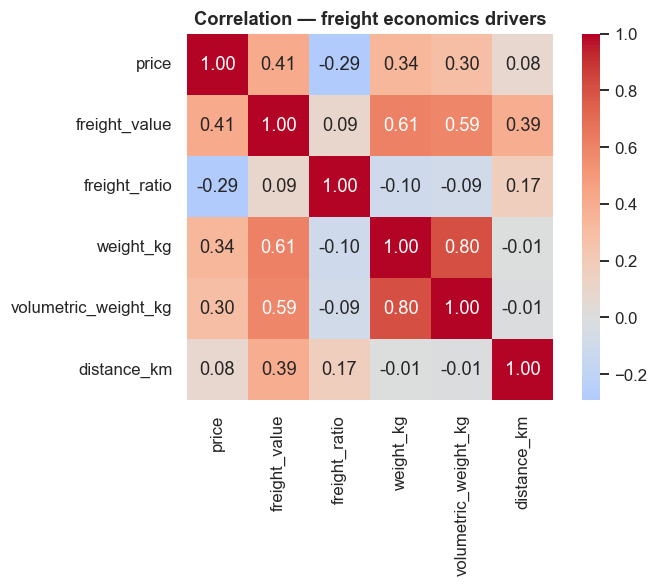

In [25]:
# correlation heatmap of the freight drivers
cols = ["price","freight_value","freight_ratio","weight_kg","volumetric_weight_kg","distance_km"]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(core[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation — freight economics drivers")
plt.tight_layout(); plt.show()

The heatmap gathers it in one place: freight leans on weight, volume and distance, and only
weakly on price. Note that **weight and volumetric weight are themselves ~0.8 correlated** — they are
two views of the same "how big is the parcel" idea, which is exactly why the chargeable-weight
`max(...)` above is the cleaner single summary of the two.

### How deterministic is freight? — do identical parcels cost the same?

If freight were purely physical, two parcels of the same weight, size **and** shipping distance should
cost about the same. They do not. Grouping items into narrow bands of weight × volume × distance and
looking at the freight *within* each band exposes a wide spread.

In [26]:
# Group items into narrow weight x volume x distance bands, then look at the spread inside each.
db = core[(core.volume_cm3 > 0) & (core.freight_value > 0)].copy()
db["wbin"] = pd.cut(db.weight_kg*1000, [0,300,500,750,1000,1500,2000,3000,5000,10000,np.inf])
db["vbin"] = pd.cut(db.volume_cm3, [0,1000,2000,4000,8000,16000,32000,np.inf])
db["dbin"] = pd.cut(db.distance_km, [0,50,100,200,300,500,750,1000,1500,2000,np.inf])
grp = db.groupby(["wbin","vbin","dbin"], observed=True)["freight_value"]
cell = grp.agg(n="size", p10=lambda s: s.quantile(.1), p50="median", p90=lambda s: s.quantile(.9))
cell = cell[cell.n >= 30].copy(); cell["p90_over_p10"] = cell.p90 / cell.p10

# share of freight variation that lines up with the (weight, volume, distance) band (well-populated cells)
big = db.groupby(["wbin","vbin","dbin"], observed=True)["freight_value"].transform("size") >= 30
sub = db[big]; cm = sub.groupby(["wbin","vbin","dbin"], observed=True).freight_value.transform("mean")
explained = 1 - ((sub.freight_value - cm)**2).sum() / ((sub.freight_value - sub.freight_value.mean())**2).sum()

print("Near-identical cells (>=30 items):", len(cell))
print("Within a typical cell, freight p10 -> p90:  R$%.1f -> R$%.1f  (%.2fx)"
      % (cell.p10.median(), cell.p90.median(), cell.p90_over_p10.median()))
print("Aligned with weight/volume/distance: %.0f%% of freight variation; "
      "~%.0f%% varies between otherwise-identical parcels." % (explained*100, (1-explained)*100))

key = cell.sort_values("n", ascending=False).index[0]   # a well-populated, tight band
ex = db[(db.wbin==key[0]) & (db.vbin==key[1]) & (db.dbin==key[2])]
print("\nSame weight/size/distance band — freight actually charged (sample):")
print(ex.sample(min(8, len(ex)), random_state=3)
      [["weight_kg","volume_cm3","distance_km","freight_value","category"]]
      .sort_values("freight_value").round(1).to_string(index=False))

Near-identical cells (>=30 items): 430
Within a typical cell, freight p10 -> p90:  R$14.1 -> R$23.3  (1.72x)
Aligned with weight/volume/distance: 53% of freight variation; ~47% varies between otherwise-identical parcels.

Same weight/size/distance band — freight actually charged (sample):
 weight_kg  volume_cm3  distance_km  freight_value              category
      0.20    2,926.00       456.80           1.80 computers_accessories
      0.20    3,600.00       389.20          14.10   luggage_accessories
      0.20    3,360.00       344.80          14.20             perfumery
      0.20    2,288.00       351.00          15.10         health_beauty
      0.20    2,304.00       371.00          16.10 computers_accessories
      0.20    2,378.00       479.80          16.40 computers_accessories
      0.20    2,816.00       396.00          17.40   musical_instruments
      0.30    3,000.00       354.50          17.60            housewares


Even among parcels of near-identical weight, size and distance, the freight in the top decile is
roughly **1.7× the bottom** (many bands 2× or more), and only about **half** of all freight variation
lines up with the weight/volume/distance band — the other half varies from one otherwise-identical
parcel to the next. That residual is not random noise: it reflects **each seller setting their own
shipping charge**, free-shipping and voucher deals, handling differences, and our own approximations
(unknown carrier divisor, straight-line rather than road distance). For problem choice this is the key
nuance — freight is **systematic enough to be worth studying, but not fully determined by the
parcel**; the seller-driven spread on identical shipments is a real structural feature of the
marketplace, not measurement error.

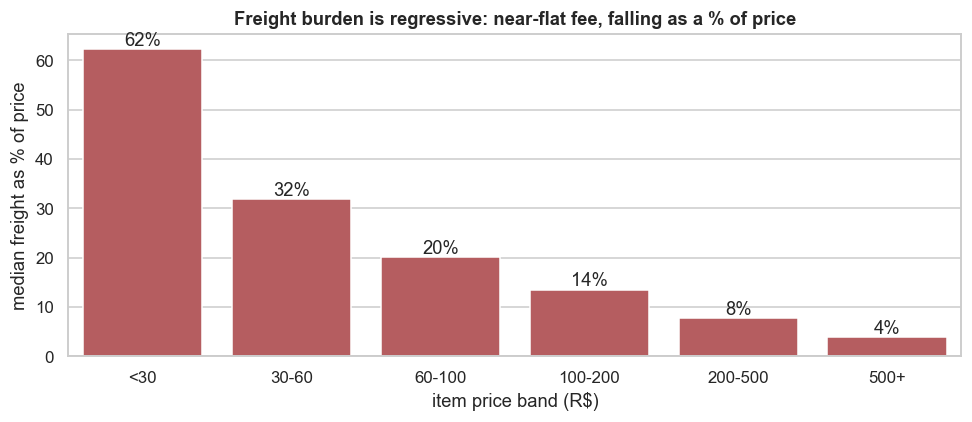

         median_freight  median_burden
price                                 
<30               14.10          62.20
30-60             15.10          31.80
60-100            16.35          20.10
100-200           18.54          13.50
200-500           21.00           7.70
500+              31.28           3.80


In [27]:
# Regressive freight: a near-flat fee is a big % of cheap items
band = pd.cut(f.price, [0,30,60,100,200,500,np.inf],
              labels=["<30","30-60","60-100","100-200","200-500","500+"])
bstats = f.groupby(band, observed=True).agg(median_freight=("freight_value","median"),
                                            median_burden=("freight_ratio","median"))
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=bstats.index.astype(str), y=(bstats.median_burden*100).values, ax=ax, color="#C44E52")
for i, v in enumerate(bstats.median_burden*100):
    ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom")
ax.set_title("Freight burden is regressive: near-flat fee, falling as a % of price")
ax.set_xlabel("item price band (R$)"); ax.set_ylabel("median freight as % of price")
plt.tight_layout(); plt.show()
print(bstats.assign(median_burden=lambda d:(d.median_burden*100).round(1)).to_string())

Median freight is roughly flat across price bands (~R$14–31), so as a **share of price** it falls
from ~60% on the cheapest items to ~4% on the dearest. A near-flat fee on a widely varying price is
**regressive by construction**: cheap items carry a disproportionate shipping burden, while expensive
items barely feel it.

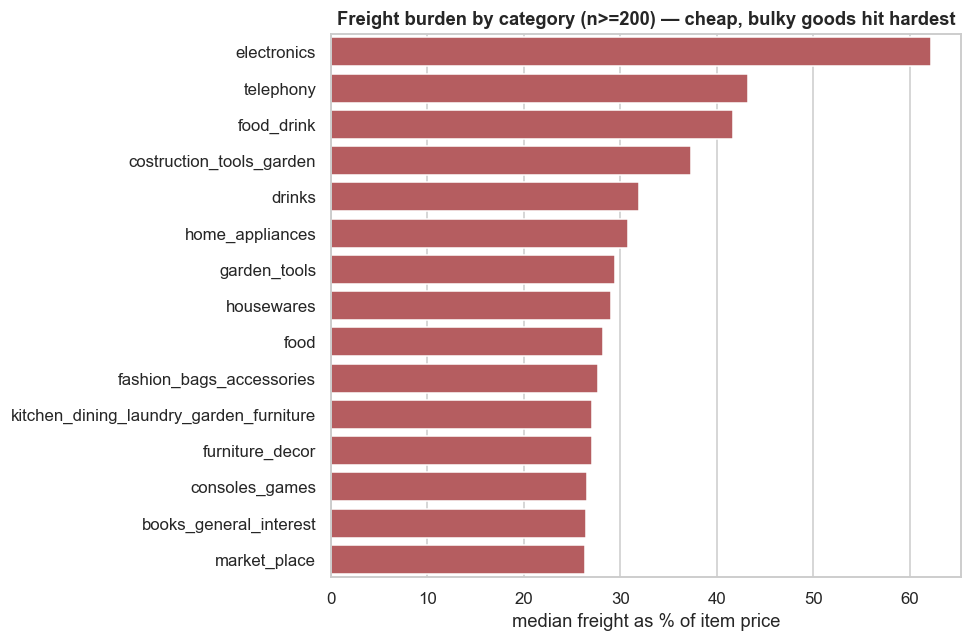

Near-identical freight, opposite burden:
               median_price  median_freight  median_burden
category                                                  
electronics           21.90           15.10          62.00
watches_gifts        129.00           15.82          12.00


In [28]:
# Freight burden by product category
catburden = (f.groupby("category")
             .agg(median_burden=("freight_ratio", "median"),
                  median_freight=("freight_value", "median"),
                  median_price=("price", "median"),
                  n=("freight_ratio", "size"))
             .query("n >= 200").sort_values("median_burden", ascending=False))
top = catburden.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=(top.median_burden*100).values, y=top.index, ax=ax, color="#C44E52")
ax.set_xlabel("median freight as % of item price"); ax.set_ylabel("")
ax.set_title("Freight burden by category (n>=200) — cheap, bulky goods hit hardest")
plt.tight_layout(); plt.show()

comp = catburden.loc[catburden.index.intersection(["electronics", "watches_gifts"])]
print("Near-identical freight, opposite burden:")
print(comp[["median_price", "median_freight", "median_burden"]]
      .assign(median_burden=lambda d: (d.median_burden*100).round(0)).to_string())

This chart is easy to misread, so it is worth being precise: electronics and watches_gifts pay
almost the **same absolute freight** (~R$15), yet electronics shows ~60% burden against ~12% for
watches — **entirely because electronics are cheap and watches are dear**, not because electronics
cost more to ship. So category acts on freight in two different ways: partly as a stand-in for
**weight and size** (heavy, bulky categories genuinely cost more to move), and here as a stand-in for
**price** (cheap categories bear a heavier *burden*). The burden ranking is a price story — a map of
who a fairer shipping policy would help most — sitting on top of the physical cost story.

**Why freight is worth pursuing (Section 7 in one line).** Freight is *material* (14% of GMV, a median
23% of item price), *structured* (it rises with weight, volume and distance — a genuine cost, not a
markup on price), and *unevenly applied* (regressive across price, and charged differently even for
near-identical parcels). Big, explainable, and structurally uneven — that combination is what makes
freight the richest thread in this dataset to build on.

## 8. Customer Reviews - what drives satisfication

In this section, we investigate the distribution of customer satisfaction levels and the key influencing factors.

### 8.1 Distribution of Reviews

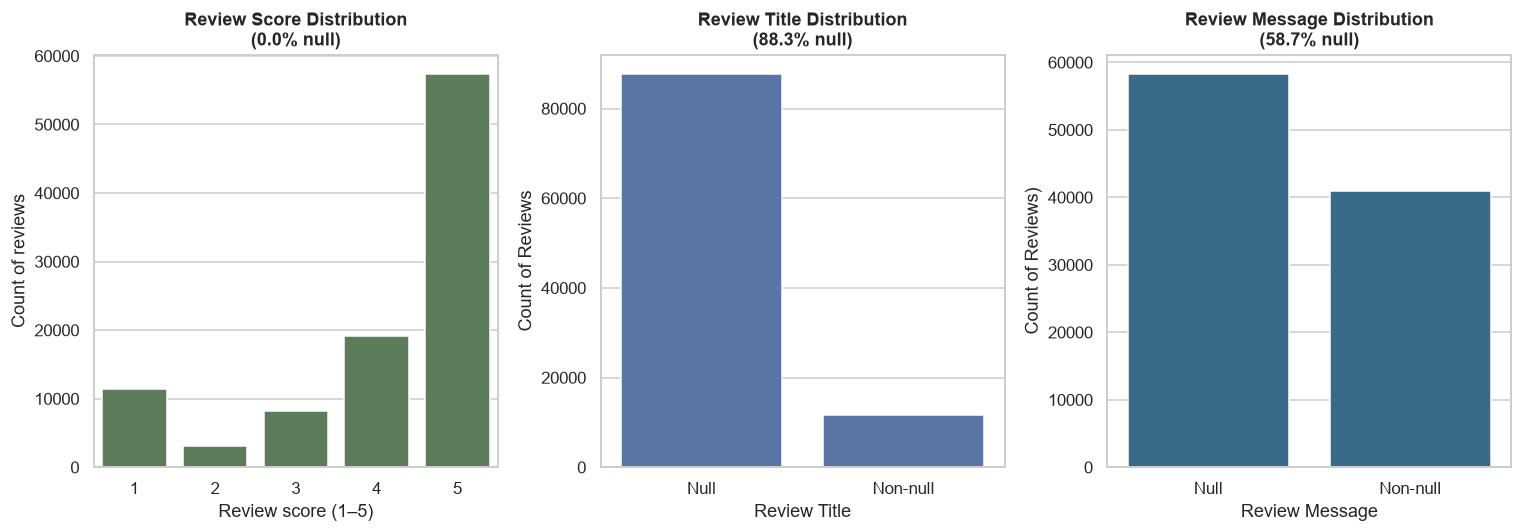

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

review_counts = t['reviews']["review_score"].value_counts().sort_index()
sns.barplot(x=review_counts.index, y=review_counts.values, ax=axes[0], color="#588157")
axes[0].set_xlabel("Review score (1–5)")
axes[0].set_ylabel("Count of reviews")
axes[0].set_title(f"Review Score Distribution\n({100-len(t['reviews']['review_score'].isna()) / len(t['reviews']['review_score'])*100}% null)")

# Plot for review_comment_title
review_title_sparsity = t['reviews']["review_comment_title"].isna().value_counts().rename({False: 'Non-null', True: 'Null'})
sns.barplot(x=review_title_sparsity.index, y=review_title_sparsity.values, ax=axes[1])
axes[1].set_xlabel("Review Title")
axes[1].set_title(f"Review Title Distribution\n({round(100-review_title_sparsity['Non-null']/(review_title_sparsity['Non-null']+review_title_sparsity['Null']) * 100, 1)}% null)")
axes[1].set_ylabel('Count of Reviews')

# Plot for review_comment_message
review_message_sparsity = t['reviews']["review_comment_message"].isna().value_counts().rename({False: 'Non-null', True: 'Null'})
sns.barplot(x=review_message_sparsity.index, y=review_message_sparsity.values, ax=axes[2], color="#2A6F97")
axes[2].set_xlabel("Review Message")
axes[2].set_title(f"Review Message Distribution\n({round(100-review_message_sparsity['Non-null']/(review_message_sparsity['Non-null']+review_message_sparsity['Null']) * 100, 1)}% null)")
axes[2].set_ylabel('Count of Reviews)')

plt.tight_layout()
plt.show()

There are three columns indicating customers' satisfaction in the reviews dataset.
* Review Score: 
    * Numerical column ranging from 1-5 with no null values, making it a useful feature to directly measure satisfation
    * Satisfaction levels are more prominent on the extremes, with significantly more 5-star than 1-star reviews (~5 times more)
* Review Title and Message: 
    * Large proportion of null values, hence might not be suitable for direct analysis without extensive imputation or feature engineering

### 8.2 Review Distribution over Time

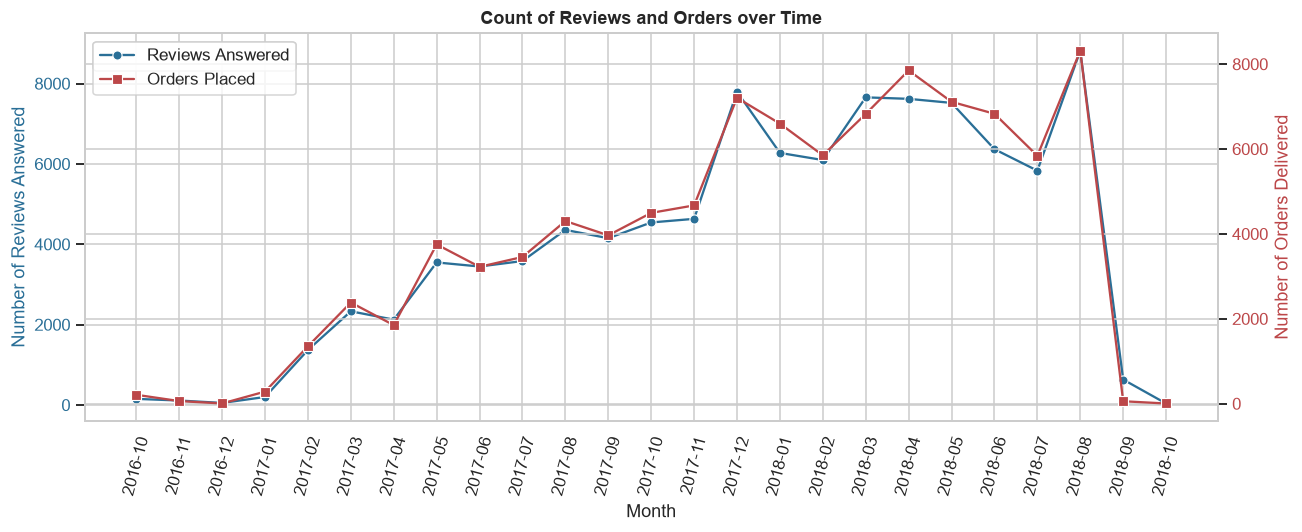

In [145]:
reviews_monthly = (t['reviews'].dropna(subset=['review_answer_timestamp'])
                     .assign(review_month=lambda x: x['review_answer_timestamp'].dt.to_period('M').astype(str))
                     .groupby('review_month')['review_id'].count()
                     .reset_index(name='num_reviews'))

orders_monthly = (t['orders']
                     .assign(delivered_month=lambda x: x['order_delivered_customer_date'].dt.to_period('M').astype(str))
                     .groupby('delivered_month')['order_id'].nunique()
                    .reset_index(name='num_orders'))

merged_data = pd.merge(reviews_monthly, orders_monthly, left_on='review_month', right_on='delivered_month', how='outer')
merged_data = merged_data.sort_values('review_month')

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.lineplot(x='review_month', y='num_reviews', data=merged_data, marker='o', color='#2A6F97', ax=ax1, label='Reviews Answered')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Reviews Answered', color='#2A6F97')
ax1.tick_params(axis='x', rotation=75)
ax1.tick_params(axis='y', labelcolor='#2A6F97')

ax2 = ax1.twinx()  # Create a twin y-axis
sns.lineplot(x='review_month', y='num_orders', data=merged_data, marker='s', color='#BC4749', ax=ax2, label='Orders Placed')
ax2.set_ylabel('Number of Orders Delivered', color='#BC4749')
ax2.tick_params(axis='y', labelcolor='#BC4749')

ax1.set_title('Count of Reviews and Orders over Time')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()


* Review and Order volume show similar trends over time. This suggests that most customers review their products within the same month of receiving them.
* One possible reason is that the platform requires reviews to be made within one month of receiving the product.
* We also observe that review volume is high relative to order volume, i.e. review completion rate is high.
* Given the short turnaround time between receiving the product and writing the review, we can infer that reviews are more focused on delivery performance and product appearance, rather than product quality or longer term usability.

### 8.3 Correlation Analysis

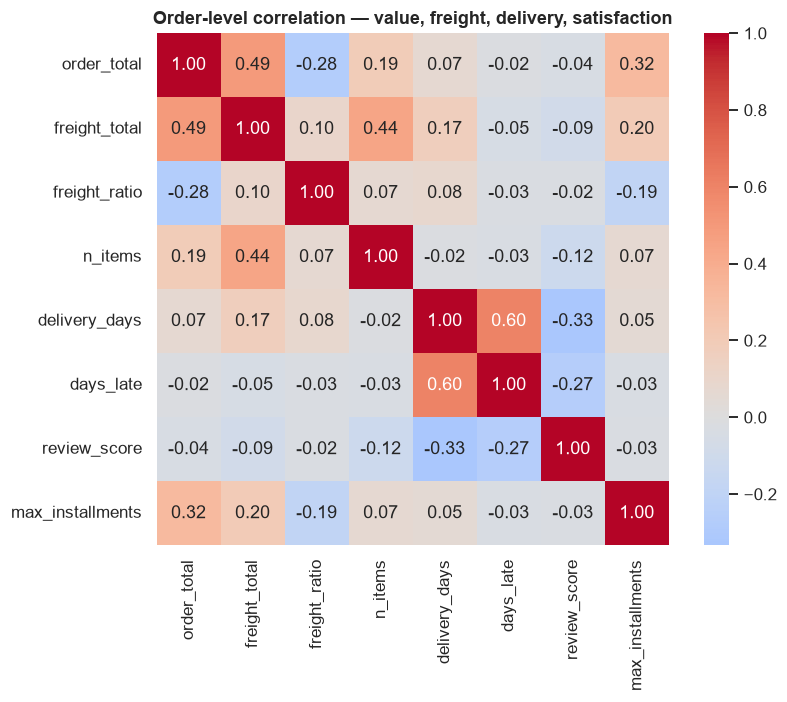

In [28]:
# Order-level relationships, on delivered orders that carry a review
rel = order[(order.order_status == "delivered") & order.review_score.notna()].copy()
num = ["order_total", "freight_total", "freight_ratio", "n_items",
       "delivery_days", "days_late", "review_score", "max_installments"]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(rel[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Order-level correlation — value, freight, delivery, satisfaction")
plt.tight_layout(); plt.show()

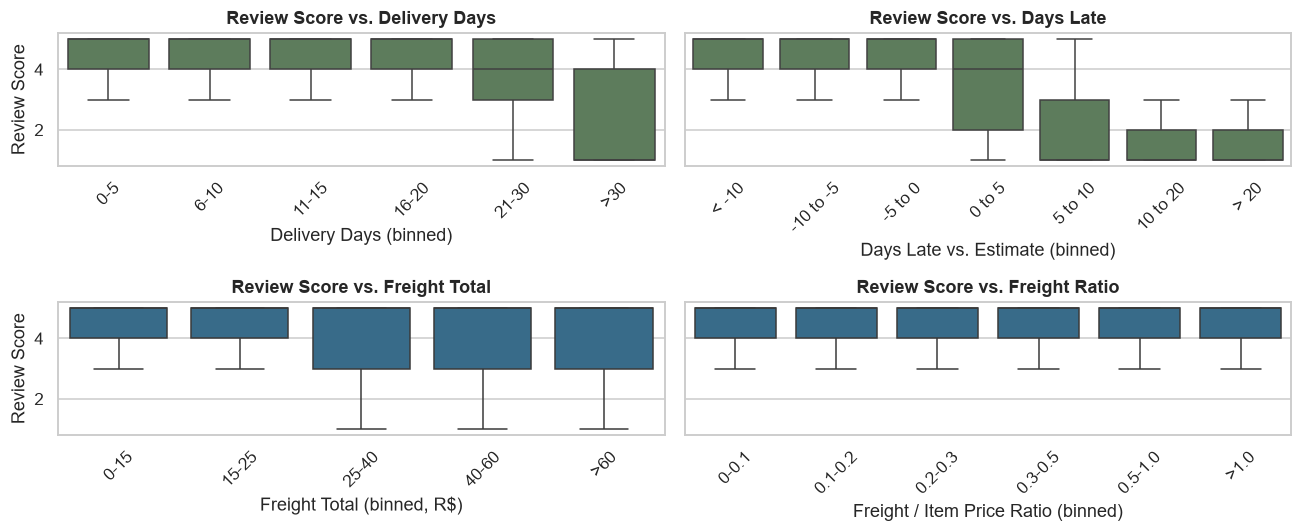

In [181]:
# Binning delivery days
delivery_bins = [0, 5, 10, 15, 20, 30, rel['delivery_days'].max() + 1]
delivery_labels = ['0-5', '6-10', '11-15', '16-20', '21-30', '>30']
rel['delivery_days_binned'] = pd.cut(rel['delivery_days'], bins=delivery_bins, labels=delivery_labels, right=False)

# Binning days late (days_late)
days_late_bins = [rel['days_late'].min() - 1, -10, -5, 0, 5, 10, 20, rel['days_late'].max() + 1]
days_late_labels = ['< -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 20', '> 20']
rel['days_late_binned'] = pd.cut(rel['days_late'], bins=days_late_bins, labels=days_late_labels, right=False)

# Binning freight total
freight_bins = [0, 15, 25, 40, 60, rel['freight_total'].max() + 1]
freight_labels = ['0-15', '15-25', '25-40', '40-60', '>60']
rel['freight_total_binned'] = pd.cut(rel['freight_total'], bins=freight_bins, labels=freight_labels, right=False)

# Binning freight ratio
freight_ratio_bins = [0, 0.1, 0.2, 0.3, 0.5, 1.0, rel['freight_ratio'].max() + 0.1]
freight_ratio_labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.5', '0.5-1.0', '>1.0']
rel['freight_ratio_binned'] = pd.cut(rel['freight_ratio'], bins=freight_ratio_bins, labels=freight_ratio_labels, right=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharey=True)

# Plot 1: Review Score vs. Delivery Days
sns.boxplot(x='delivery_days_binned', y='review_score', data=rel, ax=axes[0, 0], color="#588157", showfliers=False)
axes[0, 0].set_title('Review Score vs. Delivery Days')
axes[0, 0].set_xlabel('Delivery Days (binned)')
axes[0, 0].set_ylabel('Review Score')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Review Score vs. Days Late
sns.boxplot(x='days_late_binned', y='review_score', data=rel, ax=axes[0, 1], color="#588157", showfliers=False)
axes[0, 1].set_title('Review Score vs. Days Late')
axes[0, 1].set_xlabel('Days Late vs. Estimate (binned)')
axes[0, 1].set_ylabel('Review Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Review Score vs. Freight Total
sns.boxplot(x='freight_total_binned', y='review_score', data=rel, ax=axes[1, 0], color="#2A6F97", showfliers=False)
axes[1, 0].set_title('Review Score vs. Freight Total')
axes[1, 0].set_xlabel('Freight Total (binned, R$)')
axes[1, 0].set_ylabel('Review Score')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Review Score vs. Freight Ratio
sns.boxplot(x='freight_ratio_binned', y='review_score', data=rel, ax=axes[1, 1], color="#2A6F97", showfliers=False)
axes[1, 1].set_title('Review Score vs. Freight Ratio')
axes[1, 1].set_xlabel('Freight / Item Price Ratio (binned)')
axes[1, 1].set_ylabel('Review Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Correlation analysis shows that review score is more highly correlated with delivery performance (delivery_days, days_late) than pricing (order_total, freight_total, freight_ratio).

As delivery days and days late increases, the median review score decreases due to a growing accumulation of low ratings (1-2).

However, median review scores do not change as freight total or freight ratio increases. While low ratings start to appear with higher freight total, it does not seem affected by freight ratio.

## 9. Candidate problem exploration

### 9.1 Candidate A: Fair-freight pricing and overcharge detection

**Regression:** predict `freight_value` per item from distance, weight, volume and category.

**Classification:** flag items whose actual freight deviates abnormally from the predicted fair
value (a residual-based overcharge/undercharge flag built on top of the regression).

**Scoping checklist — Candidate A**

| Check | Verdict |
|---|---|
| Derivable target | `freight_value` is in order_items dataset; Anomaly label is derived from model residual |
| Realistic features | distance, weight, size, volume, category are all known at checkout - no data leakage |
| Sufficient signal | Strong (see section 7): freight correlates 0.61 with weight, 0.59 with volumetric weight and 0.39 with distance, well above 0.41 with price. The determinism check shows only ~53% of freight variation aligns with the weight/volume/distance band -- within bands of near-identical weight, volume and distance, freight still ranges about 1.7x from the 10th to the 90th percentile -- so there is clear predictive signal for the fair-value regression, plus a wide residual spread that is exactly the overcharge signal the classifier would target. |
| Manageable imbalance | the anomaly flag is defined by a chosen residual percentile, so its rate is controllable.  |
| Clear stakeholder | Finance/Logistics Cost Analyst. Used to audit which sellers, routes, or product types are systematically over- or under-charging freight relative to distance and weight, informing carrier renegotiation or seller freight-policy caps. |

### 9.2 Candidate B: Delivery-time / late-delivery prediction

**Regression:** predict `delivery_days`. 

**Classification:** predict `is_late` (vs Olist's estimate).

In [192]:
d.is_late.value_counts(normalize=True)

is_late
False   0.93
True    0.07
Name: proportion, dtype: float64

**Scoping checklist — Candidate B**

| Check | Verdict |
|---|---|
| Derivable target | `delivery_days` and `is_late` come from the orders dataset. |
| Realistic features | must use only pre-dispatch info (distance, product, seller, category, etc) |
| Sufficient signal | Yes (see section 5): delivery time and lateness vary strongly by geography -- SP (the seller hub) delivers in ~7 days with under 6% late, versus ~24-25 days for remote states (AM, RR, AP), with state late-rates ranging from under 3% up to 21.4% (AL). Most of the lead time is the carrier-to-customer leg (~9 of ~12 days), and the longest-transit states are not the highest-late states -- clear signal for both the delivery-days regression and the is-late classification. |
| Manageable imbalance | ~7% late — use precision/recall/F1 and stratified splits, not accuracy. |
| Clear stakeholder | Operations / customer-experience team setting delivery promises and flagging at-risk orders. |

## 10. Key insights and recommended direction (TO DO AFTER EVERYONE'S PARTS)

**What the data shows**
1. **Freight is a large, systematic cost** — ~14% of GMV, a median 23% of item price, and >25% of
   price on ~46% of items.
2. **Freight is priced off the parcel, not the price** — correlations ~0.6 (weight, volume) and ~0.4
   (distance) vs ~0.4 (price); weight and volume are ~0.8 collinear.
3. **Freight is regressive** — a near-flat fee is 60%+ of cheap items and <4% of expensive ones,
   structurally penalising cheap-but-bulky categories.
4. **Distance drives both freight and delivery time**, and there is a strong SP-vs-remote gradient.
5. **Satisfaction is driven by delivery time, not freight** — review score correlates −0.33 with
   delivery time (on-time 4.3★ vs late 2.3★) but is essentially flat across freight burden. This
   keeps the project honest about what freight does and does not explain.

**Recommended Phase 2 direction.** Take **Candidate A — fair-freight pricing + overcharge
detection** as the primary problem (one regression + one derived classification, satisfying the
dual-framing requirement), with **Candidate B (delivery/lateness)** as the companion logistics
problem if a second is pursued.

**Limitations (apply to all).** `freight_value` is revenue, not carrier cost, so no true margin
claims; distances are great-circle, not road; everything conditions on completed orders (pre-
checkout demand loss is unobservable); the window is ~2 years ending Oct 2018 with a partial final
month.

---
*Reproducibility: `RANDOM_STATE = 42` throughout; analytical tables built once in Section 3; delivery
analysis restricted to delivered orders; log transforms used for skewed monetary variables.*